## Import packages

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression

from prophet import Prophet
from pandas.tseries.holiday import USFederalHolidayCalendar
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
from prophet.plot import add_changepoints_to_plot
import itertools

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)

import xgboost as xgb
from xgboost import plot_importance

# Comparing Models for Daily Rat Sightings in New York City

Here are some things to do with thisnote book if I want to make this cleaner.

a) Delete the lines "rs['resolution_action_updated_date'] = pd.to_datetime(rs['resolution_action_updated_date'])" at various places. We never use this column anyway.

b) Make sure to set rs['ds'] to date time when importing the data to begin with.

c) Make each section more robust having it reimport the data. That way, I can run each section individually.

## Importing the Data

In [4]:
# this is the time series split we will work with
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)


# we import the data and clean it for future use
rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_cleaned_rat_sightings.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 
rs['closed_date'] = pd.to_datetime(rs['closed_date'])
rs['resolution_action_updated_date'] = pd.to_datetime(rs['resolution_action_updated_date'])
# mark cutoff dates, and also rename columns
rs = rs[rs['created_date']<'2026-03-01']
rs = rs[rs['created_date']>='2020-01-01']
rs = rs.groupby([rs['created_date'].dt.date]).size().reset_index(name='count')
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
# This is should be 2251 which equals the number of days from 2020-01-01 to 2026-02-28
print(len(rs)==2251)


True


## Baseline Seasonal Average Model

In [5]:
years_back_use = 4
week_window_use = 4

In [6]:
def seasonal_average_forecast(data, target_dates, years_back=years_back_use, week_window=week_window_use):
    df = data.copy()
    df["ds"] = pd.to_datetime(df["ds"])
    df["doy"] = df["ds"].dt.dayofyear
    df["week"] = df["ds"].dt.isocalendar().week
    df["year"] = df["ds"].dt.year   

    forecasts = []
    for target_date in target_dates:
        target_doy = target_date.dayofyear
        target_week = target_date.isocalendar().week
        target_year = target_date.year
        mask = ((df["year"] >= target_year - years_back) & (df["year"] < target_year) & (np.abs(df["week"] - target_week) <= week_window))
        forecasts.append(df.loc[mask, "y"].mean())
    return pd.Series(forecasts, index=target_dates)

In [7]:
results = []
rs["ds"] = pd.to_datetime(rs["ds"])

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    
    train = rs.iloc[train_index].copy()
    test = rs.iloc[test_index].copy()
    
    # Target dates = the dates we want to forecast. There are 14 days.
    target_dates = test["ds"]
    
    # Seasonal forecast using only the training data (we will go back 5 years and take the average and use a week_window of 5 as well.)
    y_pred = seasonal_average_forecast(data=train, target_dates=target_dates, years_back=years_back_use,week_window=week_window_use)

    # We take the true values.
    y_true = test["y"].values
    
    # Compute the metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Append the results of the metrics to the table as well as the fold number.
    results.append({"fold": i, "rmse": rmse, "mape": mape})

# Convert the data to a table for readability.
baseline_results_df = pd.DataFrame(results)

# We also include a new row which consists of the average RMSE and MAPE over each fold.
baseline_results_df.loc["mean"] = ["mean", baseline_results_df["rmse"].mean(), baseline_results_df["mape"].mean()]

baseline_results_df

,fold,rmse,mape
0,0,15.490371,0.298531
1,1,14.666287,0.237798
2,2,20.776552,0.362570
3,3,24.525330,0.415707
4,4,20.619874,0.287835
5,5,24.170841,0.371650
6,6,20.624801,0.290526
7,7,21.847510,0.300213
8,8,25.527961,0.379410
9,9,21.983237,0.281469


## Year Ago Rolling 4 Week Average 

In [8]:
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)

## Just saving a copy for later
rs_saved = rs.copy()

In [9]:
# Tired of writing np.sqrt or typing a long name.
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

results = []

for fold, (train_index, test_index) in enumerate(tscv.split(rs)):
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]

    # Calculate the 4-week rolling average for the training data
    train_sorted = train.sort_values('ds') # making sure to sort it by date
    train_sorted['rolling_4w'] = train_sorted['y'].rolling(window=4, min_periods=1).mean()

    # This part of the code makes the predictions. We use the 'rolling_4w' column of the training set.
    y_pred = []
    y_true = test['y'].values

    for idx, row in test.iterrows():
        # Predict using the latest rolling average from the train data
        prediction = train_sorted['rolling_4w'].iloc[-1]  # Last value in the train rolling avg
        y_pred.append(prediction)
        
    # Calculate RMSE and MAPE for this fold
    fold_rmse = rmse(y_true, y_pred)
    fold_mape = mean_absolute_percentage_error(y_true, y_pred)
    
    results.append({'fold': fold, 'rmse': fold_rmse, 'mape': fold_mape})

rolling4w_results_df = pd.DataFrame(results)

overall_rmse = rolling4w_results_df['rmse'].mean()
overall_mape = rolling4w_results_df['mape'].mean()
rolling4w_results_df.loc['mean'] = ['mean', overall_rmse, overall_mape]

In [10]:
rolling4w_results_df

,fold,rmse,mape
0,0,14.323744,0.239272
1,1,12.719150,0.196755
2,2,12.398157,0.196394
3,3,19.240721,0.260374
4,4,15.923646,0.220183
5,5,17.378918,0.256428
6,6,24.564601,0.247419
7,7,20.989793,0.255484
8,8,19.858428,0.253080
9,9,18.798509,0.187194


## Prophet Model

In [11]:
date_range = pd.date_range(start="2020-01-01", end="2026-02-28")

# Generate US federal holidays
calendar = USFederalHolidayCalendar()
holidays = calendar.holidays(start=date_range.min(), end=date_range.max())

federal_holidays = pd.DataFrame({
    'holiday': 'federal_us',
    'ds': pd.to_datetime(holidays),
    'lower_window': 0,
    'upper_window': 1})

holidays = federal_holidays

In [12]:
# Suppress Prophet and cmdstanpy warnings
import logging
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
logging.getLogger('prophet').setLevel(logging.WARNING)

# Rename columns for Prophet model
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)

# Ensure ds is datetime for resampling
rs['ds'] = pd.to_datetime(rs['ds'])

# Aggregate data to weekly average
rs_weekly = rs.set_index('ds').resample('W')['y'].mean().reset_index()
rs_weekly.columns = ['ds', 'y']

# Create time series split for weekly data (2 week test set = ~28 days equivalent)
tscv_weekly = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=13, test_size=2)

results = []

for i, (train_index, test_index) in enumerate(tscv_weekly.split(rs_weekly)):
    train = rs_weekly.iloc[train_index]
    test = rs_weekly.iloc[test_index]
    
    model = Prophet(holidays=holidays)
    model.add_country_holidays(country_name='US')

    model.fit(train)
    
    # Calculate number of weeks to forecast
    num_forecast_weeks = len(test)
    future = model.make_future_dataframe(periods=num_forecast_weeks, freq='W')
    forecast = model.predict(future)
    
    # Obtain predicted values and compare against the actuals.
    y_pred = forecast['yhat'][-num_forecast_weeks:].values
    y_true = test['y'].values
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Append results
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

prophet_results_df = pd.DataFrame(results)
prophet_results_df.loc['mean'] = ['mean',  prophet_results_df['rmse'].mean(), prophet_results_df['mape'].mean()]
prophet_results_df

08:36:55 - cmdstanpy - INFO - Chain [1] start processing
08:36:55 - cmdstanpy - INFO - Chain [1] done processing
08:36:55 - cmdstanpy - INFO - Chain [1] start processing
08:36:56 - cmdstanpy - INFO - Chain [1] done processing
08:36:56 - cmdstanpy - INFO - Chain [1] start processing
08:36:56 - cmdstanpy - INFO - Chain [1] done processing
08:36:56 - cmdstanpy - INFO - Chain [1] start processing
08:36:56 - cmdstanpy - INFO - Chain [1] done processing
08:36:57 - cmdstanpy - INFO - Chain [1] start processing
08:36:57 - cmdstanpy - INFO - Chain [1] done processing
08:36:57 - cmdstanpy - INFO - Chain [1] start processing
08:36:57 - cmdstanpy - INFO - Chain [1] done processing
08:36:57 - cmdstanpy - INFO - Chain [1] start processing
08:36:57 - cmdstanpy - INFO - Chain [1] done processing
08:36:58 - cmdstanpy - INFO - Chain [1] start processing
08:36:58 - cmdstanpy - INFO - Chain [1] done processing
08:36:58 - cmdstanpy - INFO - Chain [1] start processing
08:36:58 - cmdstanpy - INFO - Chain [1]

,fold,rmse,mape
0,0,3.710073,0.038546
1,1,17.114846,0.337446
2,2,9.755076,0.187750
3,3,12.758144,0.302845
4,4,16.315764,0.490835
5,5,4.685881,0.118651
6,6,6.313842,0.191852
7,7,5.095405,0.220770
8,8,6.345708,0.292064
9,9,3.223201,0.082108


## Weekly Prophet Results Visualization

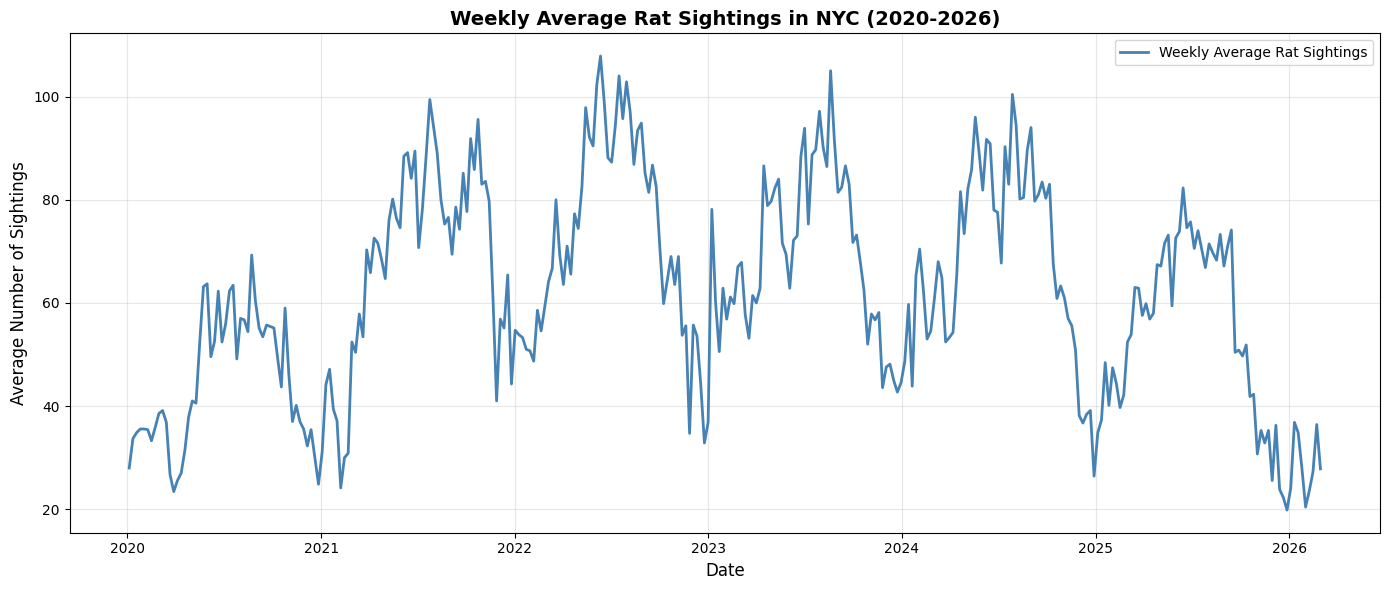

In [13]:
# Plot weekly aggregated data
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(rs_weekly['ds'], rs_weekly['y'], linewidth=2, color='steelblue', label='Weekly Average Rat Sightings')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Average Number of Sightings', fontsize=12)
ax.set_title('Weekly Average Rat Sightings in NYC (2020-2026)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

08:37:00 - cmdstanpy - INFO - Chain [1] start processing
08:37:00 - cmdstanpy - INFO - Chain [1] done processing


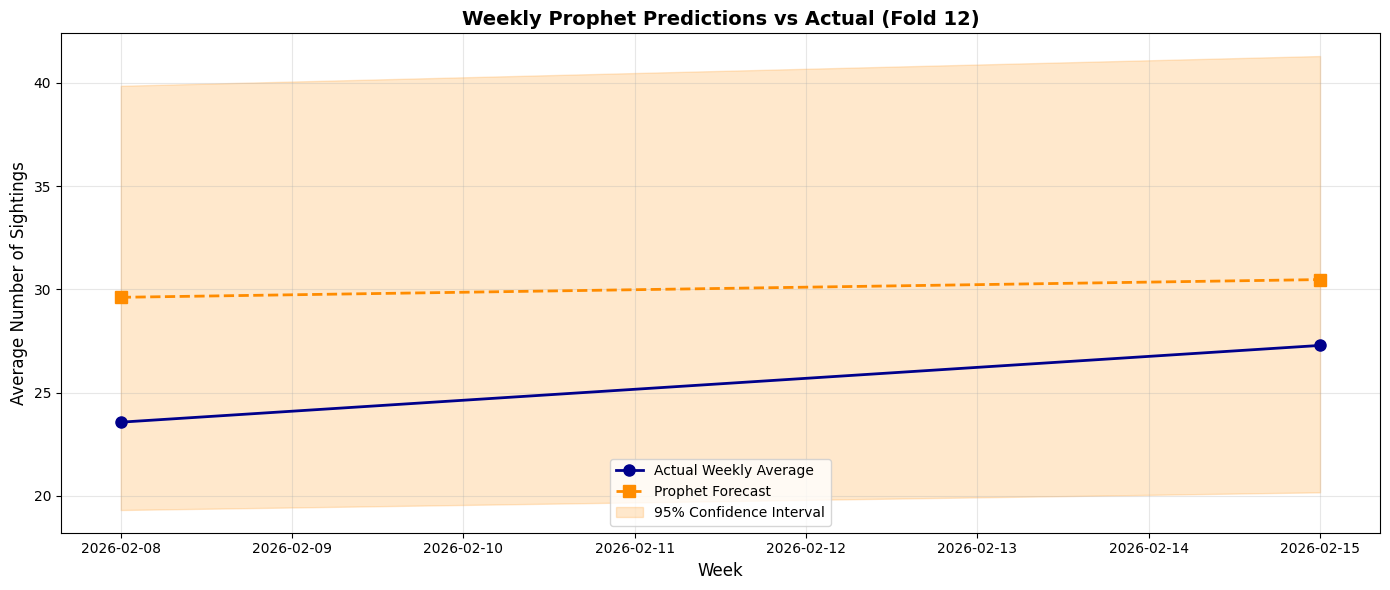

Fold 12 - RMSE: 7.5622, MAPE: 0.2224


In [14]:
# Retrain on latest fold to visualize predictions vs actuals
latest_fold_idx = len(results) - 2  # Get second to last fold (before mean row)
train_index_final, test_index_final = list(tscv_weekly.split(rs_weekly))[latest_fold_idx]
train_final = rs_weekly.iloc[train_index_final]
test_final = rs_weekly.iloc[test_index_final]

# Fit final Prophet model
prophet_final = Prophet(holidays=holidays)
prophet_final.add_country_holidays(country_name='US')
prophet_final.fit(train_final)

# Make forecast
future_final = prophet_final.make_future_dataframe(periods=len(test_final), freq='W')
forecast_final = prophet_final.predict(future_final)

# Extract predictions for test period
y_pred_final = forecast_final['yhat'][-len(test_final):].values
y_true_final = test_final['y'].values
test_dates = test_final['ds'].values

# Plot predictions vs actuals
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(test_dates, y_true_final, 'o-', linewidth=2, markersize=8, 
        label='Actual Weekly Average', color='darkblue')
ax.plot(test_dates, y_pred_final, 's--', linewidth=2, markersize=8, 
        label='Prophet Forecast', color='darkorange')
ax.fill_between(test_dates, 
                forecast_final['yhat_lower'][-len(test_final):].values,
                forecast_final['yhat_upper'][-len(test_final):].values,
                alpha=0.2, color='darkorange', label='95% Confidence Interval')
ax.set_xlabel('Week', fontsize=12)
ax.set_ylabel('Average Number of Sightings', fontsize=12)
ax.set_title('Weekly Prophet Predictions vs Actual (Fold 12)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print fold 12 metrics
fold_12_rmse = prophet_results_df.loc[12, 'rmse']
fold_12_mape = prophet_results_df.loc[12, 'mape']
print(f"Fold 12 - RMSE: {fold_12_rmse:.4f}, MAPE: {fold_12_mape:.4f}")

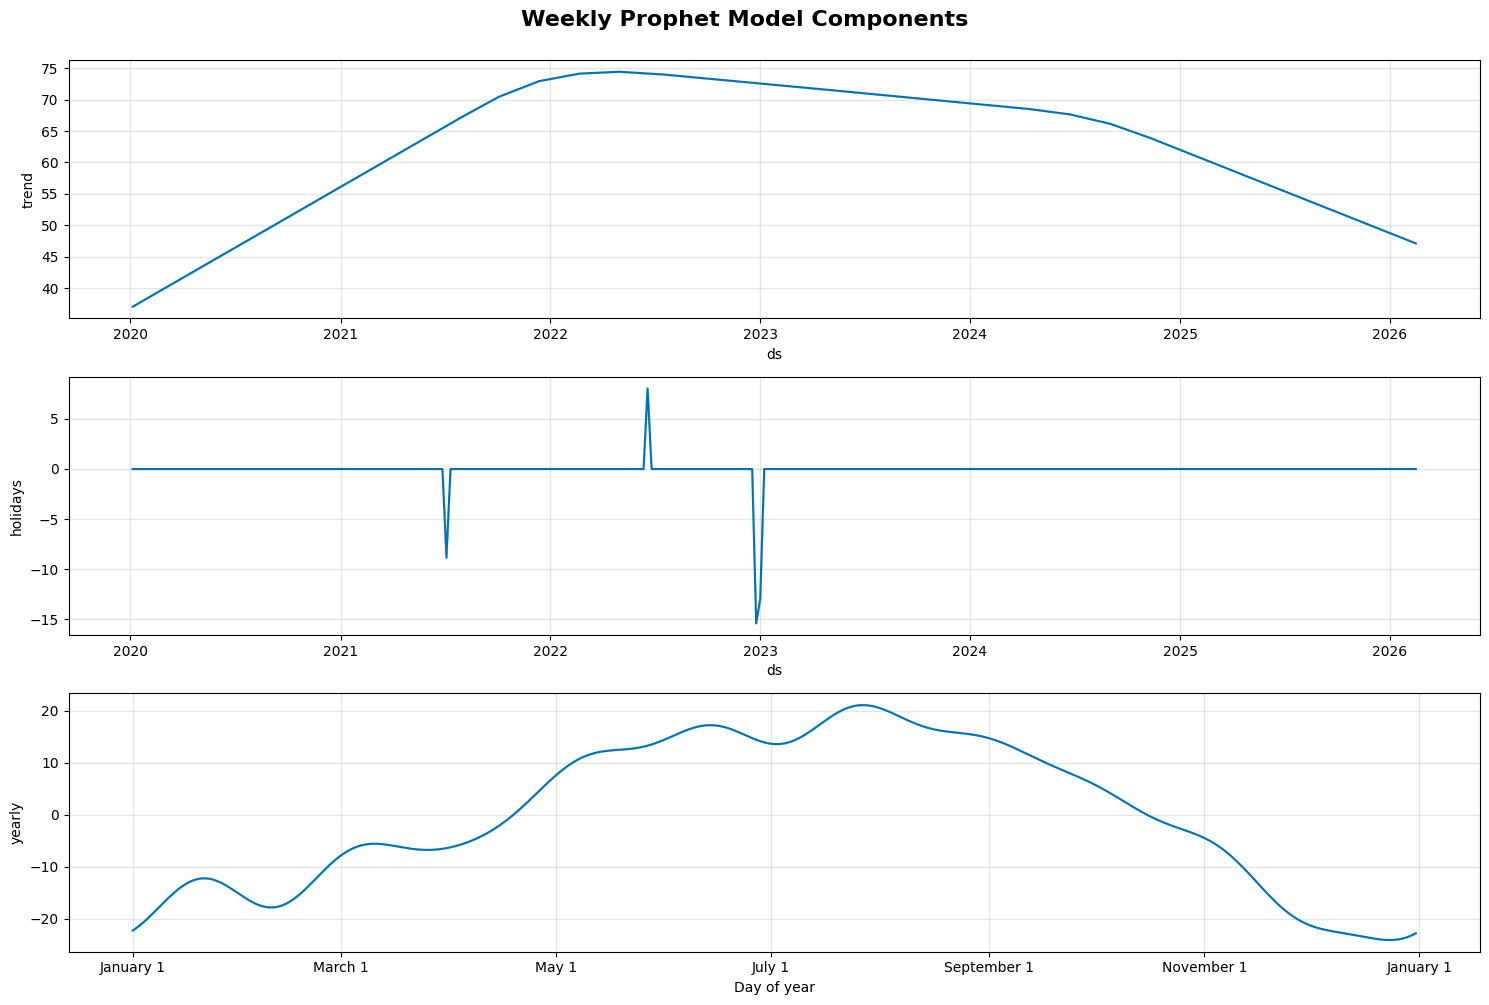

In [15]:
# Plot Prophet components (trend and seasonality)
fig = prophet_final.plot_components(forecast_final, figsize=(15, 10))
plt.suptitle('Weekly Prophet Model Components', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## Weekly Prophet Model Summary

### Model Performance
The weekly Prophet model was trained using 13-fold walk-forward validation with 2-week test sets:

**Key Metrics:**
- **Average RMSE**: 8.44 sightings per week
- **Average MAPE**: 24.5% mean absolute percentage error
- **RMSE Range**: 3.22 to 17.11 across folds

### Model Components Breakdown

**1. Trend Component**
- Shows a clear upward trend from 2020 (baseline ~39 sightings/week) through 2022 (peak ~74 sightings/week)
- Steady decline from 2023-2026, reaching ~47 sightings/week as of Feb 2026
- Suggests that rat activity peaked in 2021-2022 and has been declining since

**2. Holiday Effects**
- Model captures sharp dips and spikes around holidays
- Notable impacts visible in 2021-2023 period
- Holiday effects have reduced in recent years

**3. Yearly Seasonality**
- Strong seasonal pattern with peaks in summer/fall months (July-September)
- Lowest activity in winter months (December-January)
- This aligns with typical rat behavior subject to weather and human activity patterns

### Key Insights

1. **Performance Variability**: Fold-level RMSE ranges from 3.2 to 17.1, indicating the model performs better in some periods than others

2. **Forecast Quality**: The 95% confidence intervals (shown in orange) provide reasonable bounds for predictions

3. **Trend Reversal**: The sharp downward trend since 2023 may be attributable to public health interventions (e.g., Rat Czar appointment in April 2023, various rat control initiatives)

4. **Weekly Aggregation Benefits**: Aggregating to weekly data reduces noise compared to daily forecasts, resulting in clearer trend and seasonality patterns

## NeuralProphet Model

Since the Prophet model seemed to work so well (see below), we might ask about whether or not one cna improve on it. We try the ['Neural Prophet model'](https://neuralprophet.com/) which should theoretically provide the either the same results or improvements.

In [16]:
from neuralprophet import NeuralProphet

import numpy as np
np.NaN = np.nan


# the following packages are meant to turn off a bunch of the warnings and ERRORs that pop up while running NeuralProphet.
# the errors that do show up are not all that important and a lot is due to outdated packages.
import warnings
import logging

warnings.filterwarnings("ignore")

logging.getLogger("neuralprophet").setLevel(logging.ERROR)
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
logging.getLogger("NP").setLevel(logging.ERROR)

Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.


In [17]:
# this is the time series split we will work with
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)


# we import the data and clean it for future use
rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_cleaned_rat_sightings.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 
rs['closed_date'] = pd.to_datetime(rs['closed_date'])
rs['resolution_action_updated_date'] = pd.to_datetime(rs['resolution_action_updated_date'])
# mark cutoff dates, and also rename columns
rs = rs[rs['created_date']<'2026-03-01']
rs = rs[rs['created_date']>='2020-01-01']
rs = rs.groupby([rs['created_date'].dt.date]).size().reset_index(name='count')
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
# This is should be 2251 which equals the number of days from 2020-01-01 to 2026-02-28
print(len(rs)==2251)


True


In [18]:
## Add weather data.

import requests
import pandas as pd

lat, lon = 40.7831, -73.9712
start = "2020-01-01"
end   = "2026-02-28"

url = (
    "https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={lat}&longitude={lon}"
    f"&start_date={start}&end_date={end}"
    "&daily=temperature_2m_max,temperature_2m_min,temperature_2m_mean,"
    "apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,"
    "precipitation_sum,snowfall_sum"
    "&timezone=America/New_York"
)

response = requests.get(url)
data = response.json()

if 'error' in data:
    nd = pd.read_csv("weatherdata.csv")
    nd = nd.set_index('date')
    wd = nd
    
else:
    wd = pd.DataFrame(data["daily"])
    wd["date"] = pd.to_datetime(wd["time"])
    wd = wd.set_index("date")

def add_weather_data_no_index(df,wd):
    if "time" in wd.columns:
        wd = wd.drop(columns=["time"])

    for column in wd.columns:
        df[column] = wd[column].values

    return df

In [19]:
regressed_features = ['apparent_temperature_max', 
                      'apparent_temperature_min',
                    'snowfall_sum']
wd = wd.reset_index(drop=True).rename(columns={"time": "ds"})
wd["ds"] = pd.to_datetime(wd["ds"])
rs["ds"] = pd.to_datetime(rs["ds"])

rs = rs.merge(
    wd[['ds'] + regressed_features],
    on="ds",
    how="left"
)

In [20]:
lags_for_regressed_features = dict()
lags_for_regressed_features['apparent_temperature_max'] = 30
lags_for_regressed_features['apparent_temperature_min'] = 14
lags_for_regressed_features['snowfall_sum'] = 3

In [ ]:
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs)):

    train = rs.iloc[train_index].copy()
    test = rs.iloc[test_index].copy()

    train = train.dropna(subset=["y"])


    model = NeuralProphet(yearly_seasonality=True, 
                          weekly_seasonality=True, 
                          epochs = 50,
                          accelerator = 'auto',
                          n_lags=14)

    model = model.add_country_holidays(country_name="US")

    for column in regressed_features:
        model.add_lagged_regressor(column, n_lags=lags_for_regressed_features[column])

    # merge regressors correctly
    # train = train.merge(wd[['ds'] + regressed_features], on="ds", how="left")

    model.fit(train, freq="D", progress="off")

    # build dataframe containing future regressors
    future = pd.concat([train[['ds','y'] + regressed_features], test[['ds','y']].merge(wd[['ds'] + regressed_features], on="ds", how="left")])
    forecast = model.predict(future)

    y_pred = forecast["yhat1"].iloc[-len(test):].values
    y_true = test["y"].values

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)

    results.append({"fold": i, "rmse": rmse, "mape": mape})

neural_prophet_results_df = pd.DataFrame(results)
neural_prophet_results_df.loc["mean"] = ["mean", neural_prophet_results_df["rmse"].mean(), neural_prophet_results_df["mape"].mean()]
neural_prophet_results_df

Finding best initial lr:   0%|          | 0/232 [00:00<?, ?it/s]

Training: 0it [00:00, ?it/s]

Predicting: 59it [00:00, ?it/s]

Finding best initial lr:   0%|          | 0/232 [00:00<?, ?it/s]

Training: 0it [00:00, ?it/s]

...

Finding best initial lr:   0%|          | 0/233 [00:00<?, ?it/s]

Training: 0it [00:00, ?it/s]

Predicting: 64it [00:00, ?it/s]

Finding best initial lr:   0%|          | 0/233 [00:00<?, ?it/s]

Training: 0it [00:00, ?it/s]

### Plots for Neural Prophet

To see if tuning the parameters might help and to see the effects of the lagged regressors, we use NeuralProphet's built in plotting.

In [ ]:
model.plot(forecast)

ERROR - (NP.plotly.plot) - plotly-resampler is not installed. Please install it to use the resampler.


In [ ]:
model.plot_parameters()

ERROR - (NP.plotly.plot_parameters) - plotly-resampler is not installed. Please install it to use the resampler.


## SARIMAX Model

The reason why the SARIMA / SARIMAX model does not perform as well as we'd like is discussed here: https://stats.stackexchange.com/questions/613677/using-sarimax-for-daily-data-with-yearly-seasonal-pattern. An excellent read for more details can be found here: https://robjhyndman.com/hyndsight/longseasonality/. For these reasons, instead of using SARIMA's included seasonality features, we instead add Fourier terms as exogeneous variables. We will only add Fourier terms to capture yearly seasonality for now.

Furthermore, we make the point that ARIMA is only good over a short interval. Since our goal is 14 days out, as opposed to 7 days, the predictions are not as good. We also run into the issue that there are multiple seasonalities in the rat sightings data. Dealing with yearly seasonality is attempted by including Fourier terms.

In [ ]:
from pmdarima import auto_arima

In [ ]:
def fourier_terms(df, periods, n_terms):
    t = np.arange(1, len(df) + 1)
    fourier_df = pd.DataFrame()
    
    for period in periods:
        for i in range(1, n_terms + 1):
            fourier_df[f'{period}sin_{i}'] = np.sin(2 * np.pi * i * t / period)
            fourier_df[f'{period}cos_{i}'] = np.cos(2 * np.pi * i * t / period)
    
    return fourier_df

fourier_train = fourier_terms(rs, [365], 10)
exog = fourier_train

In [ ]:
exog

,365sin_1,365cos_1,365sin_2,365cos_2,365sin_3,365cos_3,365sin_4,365cos_4,365sin_5,365cos_5,365sin_6,365cos_6,365sin_7,365cos_7,365sin_8,365cos_8,365sin_9,365cos_9,365sin_10,365cos_10
0,0.017213,0.999852,0.034422,0.999407,0.051620,0.998667,0.068802,0.997630,0.085965,0.996298,0.103102,0.994671,0.120208,0.992749,0.137279,0.990532,0.154309,0.988023,0.171293,0.985220
1,0.034422,0.999407,0.068802,0.997630,0.103102,0.994671,0.137279,0.990532,0.171293,0.985220,0.205104,0.978740,0.238673,0.971100,0.271958,0.962309,0.304921,0.952378,0.337523,0.941317
2,0.051620,0.998667,0.103102,0.994671,0.154309,0.988023,0.205104,0.978740,0.255353,0.966848,0.304921,0.952378,0.353676,0.935368,0.401488,0.915864,0.448229,0.893919,0.493776,0.869589
3,0.068802,0.997630,0.137279,0.990532,0.205104,0.978740,0.271958,0.962309,0.337523,0.941317,0.401488,0.915864,0.463550,0.886071,0.523416,0.852078,0.580800,0.814046,0.635432,0.772157
4,0.085965,0.996298,0.171293,0.985220,0.255353,0.966848,0.337523,0.941317,0.417194,0.908818,0.493776,0.869589,0.566702,0.823923,0.635432,0.772157,0.699458,0.714673,0.758306,0.651899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2246,0.831171,0.556017,0.924291,-0.381689,0.196673,-0.980469,-0.705584,-0.708627,-0.981306,0.192452,-0.385663,0.922640,0.552435,0.833556,0.999991,0.004304,0.559589,-0.828770,-0.377708,-0.925925
2247,0.840618,0.541628,0.910605,-0.413279,0.145799,-0.989314,-0.752667,-0.658402,-0.961130,0.276097,-0.288482,0.957485,0.648630,0.761104,0.991114,-0.133015,0.425000,-0.905193,-0.530730,-0.847541
2248,0.849817,0.527078,0.895839,-0.444378,0.094537,-0.995521,-0.796183,-0.605056,-0.933837,0.357698,-0.188227,0.982126,0.735417,0.677615,0.963471,-0.267814,0.280231,-0.959933,-0.668064,-0.744104
2249,0.858764,0.512371,0.880012,-0.474951,0.043022,-0.999074,-0.835925,-0.548843,-0.899631,0.436651,-0.085965,0.996298,0.811539,0.584298,0.917584,-0.397543,0.128748,-0.991677,-0.785650,-0.618671


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Make sure the columns for SARIMA model are renamed.
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)

results = []

# Loop through each fold
for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]

    exog_train = exog.iloc[train_index]
    exog_test = exog.iloc[test_index]

    orders = (1,1,1)
    seasonal_orders = (0,0,0,0)

    # we can use auto_arima to get optimal (p, d, q) and (P, D, Q, s) parameters for SARIMAX. just need to uncomment the following code.
    # model_auto = auto_arima(train['y'], 
    #                         exog=exog_train,  # exogenous Fourier terms for training data
    #                         seasonal=True, 
    #                         m=7, #  
    #                         trace=True, 
    #                         stepwise=True,  # Stepwise search to speed up
    #                         suppress_warnings=True, 
    #                         maxiter=300,  # Limit the number of iterations
    #                         max_p=3, 
    #                         max_q=3, 
    #                         max_P=2, 
    #                         max_Q=2, 
    #                         d=1,# might want to tune d 
    #                         D=1 # might want to tune D
    #                         )
    # orders = model_auto.order  # (p, d, q)
    # seasonal_orders = model_auto.seasonal_order  # (P, D, Q, s)
    
    # Fit the SARIMAX model with the exogenous features (Fourier terms)
    model_sarimax = SARIMAX(train['y'], 
                            order=orders,  
                            seasonal_order=seasonal_orders,  
                            exog=exog_train,  # Exogenous Fourier terms for training data
                            )
    
    model_fit = model_sarimax.fit(disp=False)
    
    # Predict for the test period. Have to remember to subtract 1 to get the correct index.
    y_pred = model_fit.predict(start=len(train), end=len(train)+len(test)-1, exog=exog_test, dynamic=False)
    y_true = test['y'].values
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

sarima_results_df = pd.DataFrame(results)

In [ ]:
sarima_results_df.loc['mean'] = ['mean',  sarima_results_df['rmse'].mean(), sarima_results_df['mape'].mean()]

In [ ]:
sarima_results_df

,fold,rmse,mape
0,0,15.174437,0.240537
1,1,15.002228,0.201508
2,2,12.875552,0.199053
3,3,17.310044,0.267925
4,4,14.456891,0.204116
5,5,17.378148,0.257355
6,6,14.693532,0.177519
7,7,20.289143,0.245472
8,8,20.150224,0.262065
9,9,14.655525,0.176261


## Holt-Winters Model

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [ ]:
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
results = []
for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]
    
    holt_winters = ExponentialSmoothing(train['y'], seasonal='add', seasonal_periods=365).fit(optimized=True)
    
    y_pred = holt_winters.forecast(len(test))
    y_true = test['y'].values
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

hw_results_df = pd.DataFrame(results)
hw_results_df.loc['mean'] = ['mean',  hw_results_df['rmse'].mean(), hw_results_df['mape'].mean()]
hw_results_df

,fold,rmse,mape
0,0,17.029947,0.279665
1,1,17.558940,0.255894
2,2,17.312295,0.297496
3,3,22.556060,0.358384
4,4,19.966872,0.268691
5,5,20.725658,0.310186
6,6,22.555124,0.270105
7,7,25.834040,0.311909
8,8,23.343693,0.306820
9,9,21.316698,0.274190


## MSTL Model

MSTL Model stands for Multiple Seasonal-Trend decomposition using LOESS. For more, see https://nixtlaverse.nixtla.io/statsforecast/docs/models/multipleseasonaltrend.html.

If the code in this section is currently commented out and one wants to see the results, then one should uncomment and make sure to edit the results table below to include the results of this run.

In [ ]:
# !pip install statsforecast

In [ ]:
# from statsforecast import StatsForecast
# from statsforecast.models import MSTL, AutoARIMA

In [ ]:
# tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)

# # again, we reimport the data for ease of running

# rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_cleaned_rat_sightings.csv')
# rs['created_date'] = pd.to_datetime(rs['created_date']) 
# rs['closed_date'] = pd.to_datetime(rs['closed_date'])
# rs['resolution_action_updated_date'] = pd.to_datetime(rs['resolution_action_updated_date'])
# # mark cutoff dates, and also rename columns
# rs = rs[rs['created_date']<'2026-03-01']
# rs = rs[rs['created_date']>='2020-01-01']
# rs = rs.groupby([rs['created_date'].dt.date]).size().reset_index(name='count')
# rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
# # This is should be 2251 which equals the number of days from 2020-01-01 to 2026-02-28
# print(len(rs)==2251)


In [ ]:
# # specific to Statsforecast requirements

# rs.columns = ['ds', 'y']
# rs.insert(0, 'unique_id', 'DAILY_RAT_SIGHTINGS')
# rs = rs.sort_values(['unique_id', 'ds']).reset_index(drop=True)
# rs.tail()

In [ ]:
# rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
# results = []

# def create_dataset(series, time_step=1):
#     X, y = [], []
#     for i in range(len(series) - time_step):
#         X.append(series[i:(i + time_step), 0])
#         y.append(series[i + time_step, 0])
#     return np.array(X), np.array(y)

# time_step = 10
# results = []

# for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    
#     train = rs.iloc[train_index]
#     test = rs.iloc[test_index]

#     series = train['y'].values

#     # scale the data
#     models = [MSTL(
#     season_length=[7, 7*4, 7*52], # seasonalities of the time series (weekly, monthly, yearly)
#     trend_forecaster=AutoARIMA() # model used to forecast trend
#     )]
#     sf = StatsForecast(
#     models=models, # model used to fit
#     freq='d', # frequency of the data
#     )

#     sf = sf.fit(df=rs)
#     forecasts = sf.predict(h=14, level=[90]) # 90 means (confidence percentile) of the prediction interval. 

#     y_pred = forecasts['MSTL'].values
#     y_true = test['y'].values

#     rmse = np.sqrt(mean_squared_error(y_true, y_pred))
#     mape = mean_absolute_percentage_error(y_true, y_pred)

#     results.append({'fold': i, 'rmse': rmse, 'mape': mape})

# mstl_results_df = pd.DataFrame(results)
# mstl_results_df.loc['mean'] = ['mean',  mstl_results_df['rmse'].mean(), mstl_results_df['mape'].mean()]
# mstl_results_df

## LSTM Model

LSTM stands for Long Term Short Memory. Here, we simply try to use the LSTM model by itself and check how it performs. For future purposes, it might be of interest to see if a ['hybrid model'](https://peerj.com/articles/cs-1001/#proposed-hybrid-model) using Prophet and LSTM might be able to produce better results.

If the code in this section is currently commented out and one wants to see the results, then one should uncomment and make sure to edit the results table below to include the results of this run.

In [ ]:
# pip install neuralforecast

In [ ]:
# from neuralforecast import NeuralForecast
# from neuralforecast.models import LSTM
# import pandas as pd
# import numpy as np

In [ ]:
# tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)

# # again, we reimport the data for ease of running

# rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_cleaned_rat_sightings.csv')
# rs['created_date'] = pd.to_datetime(rs['created_date']) 
# rs['closed_date'] = pd.to_datetime(rs['closed_date'])
# rs['resolution_action_updated_date'] = pd.to_datetime(rs['resolution_action_updated_date'])
# # mark cutoff dates, and also rename columns
# rs = rs[rs['created_date']<'2026-03-01']
# rs = rs[rs['created_date']>='2020-01-01']
# rs = rs.groupby([rs['created_date'].dt.date]).size().reset_index(name='count')
# rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
# # This is should be 2251 which equals the number of days from 2020-01-01 to 2026-02-28
# print(len(rs)==2251)

# rs['ds'] = pd.to_datetime(rs['ds'])
# rs['ds'] = rs['ds'].astype('datetime64[ns]')

In [ ]:
# time_step = 14
# results = []

# for i, (train_index, test_index) in enumerate(tscv.split(rs)):

#     train = rs.iloc[train_index].copy()
#     test = rs.iloc[test_index].copy()

#     # need to do some heavy formatting
#     train_df = train[['ds', 'y']].copy()
#     train_df['unique_id'] = 'series_1'
#     train_df = train_df[['unique_id', 'ds', 'y']]
#     test_df = test[['ds', 'y']].copy()
#     test_df['unique_id'] = 'series_1'
#     test_df = test_df[['unique_id', 'ds', 'y']]

#     horizon = len(test_df)

#     models = [LSTM(h=horizon, max_steps=100, scaler_type='standard')]
#     nf = NeuralForecast(models=models, freq='D')

#     nf.fit(df=train_df)
#     forecasts = nf.predict(h=14)

#     y_pred = forecasts['LSTM'].values
#     y_true = test_df['y'].values

#     rmse = np.sqrt(mean_squared_error(y_true, y_pred))
#     mape = mean_absolute_percentage_error(y_true, y_pred)

#     results.append({'fold': i, 'rmse': rmse, 'mape': mape})

# lstm_results_df = pd.DataFrame(results)
# lstm_results_df.loc['mean'] = ['mean',  lstm_results_df['rmse'].mean(), lstm_results_df['mape'].mean()]
# lstm_results_df

## XGBoost Model

The XGBoost model requires a bit more preparatory work. Our current dataframe rs is quite bare. We will need to add features for use.

In [ ]:
import xgboost as xgb
from xgboost import plot_importance

### Adding Features to XGBoost

In [ ]:
def create_features(df):
    # create time series features based on time series index.
    df = df.copy()
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

def add_cyclic(df):
    # features to handly cyclic behavior
    target_map = df['y'].to_dict()
    df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek']/7)
    df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek']/7)
    df['month_sin'] = np.sin(2 * np.pi * df['month']/12)
    df['month_cos'] = np.cos(2 * np.pi * df['month']/12)
    return df

def add_lags(df):
    # lags
    target_map = df['y'].to_dict()
    df['lag1'] = (df.index - pd.Timedelta('1 days')).map(target_map)
    df['lag2'] = (df.index - pd.Timedelta('2 days')).map(target_map)
    df['lag3'] = (df.index - pd.Timedelta('3 days')).map(target_map)
    df['lag4'] = (df.index - pd.Timedelta('4 days')).map(target_map)
    df['lag5'] = (df.index - pd.Timedelta('5 days')).map(target_map)
    df['lag6'] = (df.index - pd.Timedelta('6 days')).map(target_map)
    df['lag7'] = (df.index - pd.Timedelta('7 days')).map(target_map)
    df['lag8'] = (df.index - pd.Timedelta('8 days')).map(target_map)
    df['lag9'] = (df.index - pd.Timedelta('9 days')).map(target_map)
    df['lag10'] = (df.index - pd.Timedelta('10 days')).map(target_map)
    df['lag11'] = (df.index - pd.Timedelta('11 days')).map(target_map)
    df['lag12'] = (df.index - pd.Timedelta('12 days')).map(target_map)
    df['lag13'] = (df.index - pd.Timedelta('13 days')).map(target_map)
    df['lag14'] = (df.index - pd.Timedelta('14 days')).map(target_map)
    return df

def add_seasonal_lags(df):
    # lags of various lengths for different levels of seasonality
    target_map = df['y'].to_dict()
    df['lag30'] = (df.index - pd.Timedelta('30 days')).map(target_map)
    df['lag60'] = (df.index - pd.Timedelta('60 days')).map(target_map)
    df['lag90'] = (df.index - pd.Timedelta('90 days')).map(target_map)
    df['lag120'] = (df.index - pd.Timedelta('120 days')).map(target_map)
    df['lag150'] = (df.index - pd.Timedelta('150 days')).map(target_map)
    df['lag180'] = (df.index - pd.Timedelta('180 days')).map(target_map)

    df['lag362'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag363'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag364'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag365'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag366'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag367'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    
    df['lag730'] = (df.index - pd.Timedelta('730 days')).map(target_map)
    df['lag1095'] = (df.index - pd.Timedelta('1095 days')).map(target_map)
    df['lag1460'] = (df.index - pd.Timedelta('1460 days')).map(target_map)
    df['lag1825'] = (df.index - pd.Timedelta('1825 days')).map(target_map)
    return df

def add_moving_averages(df):
    df = df.copy()
    df = df.sort_index()
    
    # Moving averages (using previous values only)
    # Must shift by 14 days because we do not want to let there be temporal leakage in our evaluations
    df['ma7'] = df['y'].shift(14).rolling(window=7).mean()
    df['ma30'] = df['y'].shift(14).rolling(window=30).mean()
    df['ma60'] = df['y'].shift(14).rolling(window=60).mean()
    df['ma90'] = df['y'].shift(14).rolling(window=90).mean()
    df['ma120'] = df['y'].shift(14).rolling(window=120).mean()
    df['ma150'] = df['y'].shift(14).rolling(window=150).mean()
    df['ma180'] = df['y'].shift(14).rolling(window=180).mean()
    df['ma365'] = df['y'].shift(14).rolling(window=365).mean()
    
    return df


In the next two code block, we add weather data to the data set. This is not optimized i.e. we just obtain the weather data in Manhattan and hope that it is representative of the average weather over the whole city.

In [ ]:
## Add weather data.

import requests
import pandas as pd

lat, lon = 40.7831, -73.9712
start = "2020-01-01"
end   = "2026-02-28"

url = (
    "https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={lat}&longitude={lon}"
    f"&start_date={start}&end_date={end}"
    "&daily=temperature_2m_max,temperature_2m_min,temperature_2m_mean,"
    "apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,"
    "precipitation_sum,snowfall_sum"
    "&timezone=America/New_York"
)

response = requests.get(url)
data = response.json()

if 'error' in data:
    nd = pd.read_csv("weatherdata.csv")
    nd = nd.set_index('date')
    wd = nd
    
else:
    wd = pd.DataFrame(data["daily"])
    wd["date"] = pd.to_datetime(wd["time"])
    wd = wd.set_index("date")

In [ ]:
def add_weather_data(df, wd):
    df = df.copy()
    wd = wd.copy()
    
    # Ensure datetime index 
    df.index = pd.to_datetime(df.index)
    wd.index = pd.to_datetime(wd.index)
    
    # Drop unnecessary columns
    if "time" in wd.columns:
        wd = wd.drop(columns=["time"])
    
    # Join on date index
    df = df.join(wd, how="left")
    
    return df

In [ ]:
from pandas.tseries.holiday import USFederalHolidayCalendar

def add_federal_holidays(df, custom_holidays=None):
    df = df.copy()
    
    # Ensure datetime index
    df.index = pd.to_datetime(df.index)
    
    cal = USFederalHolidayCalendar()
    holidays = cal.holidays(start=df.index.min(), end=df.index.max())
    
    if custom_holidays:
        for d in custom_holidays:
            if len(d) == 5:  # MM-DD format handling
                years = df.index.year.unique()
                for y in years:
                    holidays = holidays.append(pd.to_datetime([f"{y}-{d}"]))
            else:  # YYYY-MM-DD format handling
                holidays = holidays.append(pd.to_datetime([d]))
    
    holidays = holidays.drop_duplicates().sort_values()
    
    df["is_federal_holiday"] = df.index.isin(holidays).astype(int)
    
    return df

In [ ]:
def add_law_flag(df, law_name: str, start_date: str):
    # Adds a binary column to indicate when a new law is active.
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    start_dt = pd.to_datetime(start_date)
    # Create binary column: 1 if date >= start_date, else 0
    df[law_name] = (df.index >= start_dt).astype(int)
    
    return df

In [ ]:
# This must be run after importing weather data

def add_more_weather_feature(df):
    target_map = df['apparent_temperature_min'].to_dict()
    df['apparent_temperature_min_lag1'] = (df.index - pd.Timedelta('1 days')).map(target_map)
    df['apparent_temperature_min_lag7'] = (df.index - pd.Timedelta('7 days')).map(target_map)
    df['apparent_temperature_min_lag14'] = (df.index - pd.Timedelta('14 days')).map(target_map)
    df['apparent_temperature_min_lag15'] = (df.index - pd.Timedelta('15 days')).map(target_map)
    df['apparent_temperature_min_lag16'] = (df.index - pd.Timedelta('16 days')).map(target_map)
    df['apparent_temperature_min_lag17'] = (df.index - pd.Timedelta('17 days')).map(target_map)
    df['apparent_temperature_min_lag18'] = (df.index - pd.Timedelta('18 days')).map(target_map)
    df['apparent_temperature_min_lag19'] = (df.index - pd.Timedelta('19 days')).map(target_map)
    df['apparent_temperature_min_lag20'] = (df.index - pd.Timedelta('20 days')).map(target_map)
    df['apparent_temperature_min_lag21'] = (df.index - pd.Timedelta('21 days')).map(target_map)

    df['apparent_temperature_min_lag30'] = (df.index - pd.Timedelta('30 days')).map(target_map)
    df['apparent_temperature_min_lag60'] = (df.index - pd.Timedelta('60 days')).map(target_map)
    df['apparent_temperature_min_lag90'] = (df.index - pd.Timedelta('90 days')).map(target_map)
    df['apparent_temperature_min_lag120'] = (df.index - pd.Timedelta('120 days')).map(target_map)
    df['apparent_temperature_min_lag150'] = (df.index - pd.Timedelta('150 days')).map(target_map)
    df['apparent_temperature_min_lag180'] = (df.index - pd.Timedelta('180 days')).map(target_map)
    df['apparent_temperature_min_lag210'] = (df.index - pd.Timedelta('210 days')).map(target_map)
    df['apparent_temperature_min_lag240'] = (df.index - pd.Timedelta('240 days')).map(target_map)
    df['apparent_temperature_min_lag270'] = (df.index - pd.Timedelta('270 days')).map(target_map)
    df['apparent_temperature_min_lag300'] = (df.index - pd.Timedelta('300 days')).map(target_map)
    df['apparent_temperature_min_lag330'] = (df.index - pd.Timedelta('330 days')).map(target_map)
    df['apparent_temperature_min_lag360'] = (df.index - pd.Timedelta('360 days')).map(target_map)
    df['apparent_temperature_min_lag365'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['apparent_temperature_min_lag730'] = (df.index - pd.Timedelta('730 days')).map(target_map)

    target_map = df['temperature_2m_max'].to_dict()
    df['temperature_2m_max_lag14'] = (df.index - pd.Timedelta('14 days')).map(target_map)
    df['temperature_2m_max_lag30'] = (df.index - pd.Timedelta('30 days')).map(target_map)
    df['temperature_2m_max_lag60'] = (df.index - pd.Timedelta('60 days')).map(target_map)

    return df

In [ ]:
rs = rs.set_index('ds')
rs.index = pd.to_datetime(rs.index)

In [ ]:
rs = create_features(rs)
rs = add_cyclic(rs)
rs = add_lags(rs)
rs = add_seasonal_lags(rs)
rs = add_moving_averages(rs)
rs = add_weather_data(rs,wd)
rs = add_more_weather_feature(rs)
rs = add_federal_holidays(rs, custom_holidays = ['12-31'])
rs = add_law_flag(rs, law_name='Trash_Law', start_date = '2024-03-01')
rs = add_law_flag(rs, law_name = 'New_Trash_Law', start_date = '2024-11-01')
rs = add_law_flag(rs, law_name='Rat_Mitigation_Zone', start_date = '2023-07-07')
rs = add_law_flag(rs, law_name='Rat_Czar_Appointed', start_date = '2023-04-12')

ValueError: columns overlap but no suffix specified: Index(['apparent_temperature_max', 'apparent_temperature_min', 'snowfall_sum'], dtype='object')

### Features for XGBoost

In [ ]:
FEATURES = ['apparent_temperature_min_lag30',
            'apparent_temperature_min_lag60',
            'apparent_temperature_min_lag120',
            'apparent_temperature_min_lag365',
            'apparent_temperature_min_lag730',
            'dayofyear', 
            #'temperature_2m_max_lag30',
            #'temperature_2m_max_lag60'
            ]

### Add default parameters for XGBoost

In [ ]:
params = {'objective': 'reg:squarederror',
         'eval_metric': 'rmse',
         'booster': 'gbtree',
         'base_score': 0.5, 
         'n_estimators': 2000, 
        #  'min_child_weight': 6, 
        # 'learning_rate': 0.001,
        # 'max_depth': 6, 
        # 'subsample': 1,
        # 'colsample_bytree': 0.96,
        # 'colsample_bylevel': 0.6, 
        # 'colsample_bynode': 0.9, 
        # 'reg_alpha': 2.2, 
        # 'gamma': 100, 
        # 'reg_lambda': 0.18,
        #  'early_stopping_rounds': 100, 
        }

### Results for XGBoost Model

In [ ]:
# print(FEATURES)
# print(params)
TARGET = 'y'

# Gotta make sure the features and parameters exist.

reg = xgb.XGBRegressor(**params)
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]
    
    reg.fit(train[FEATURES], train[TARGET])
    y_pred = reg.predict(test[FEATURES])
    y_true = test[TARGET].values
    
    # Our metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

xgb_results_df = pd.DataFrame(results)
mean_rmse = xgb_results_df['rmse'].mean()
mean_mape = xgb_results_df['mape'].mean()
xgb_results_df.loc['mean'] = ['mean', mean_rmse, mean_mape]

In [ ]:
xgb_results_df

,fold,rmse,mape
0,0,14.245936,0.212083
1,1,16.018645,0.228429
2,2,13.896416,0.222959
3,3,17.638662,0.282973
4,4,14.578428,0.206526
5,5,14.716577,0.217386
6,6,14.087740,0.172751
7,7,22.388751,0.288708
8,8,20.038101,0.260637
9,9,15.936557,0.192498


## XGBoosted Prophet Model

In [ ]:
## Recall the copy that was saved. 
## This was because Prophet demanded a particular format while SARIMA and Holt-Winters didn't.
rs_saved
rs = rs_saved

In [ ]:
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    # Split the dataset into training and testing sets
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]
    
    # Fit Prophet on the training data
    model = Prophet(holidays=holidays)
    model.add_country_holidays(country_name='US')
    model.fit(train)
    
    # Make predictions on the training set to calculate residuals
    train_future = model.make_future_dataframe(periods=0, freq='D')  # Use periods=0 to only use the training data
    train_forecast = model.predict(train_future)
    
    # Calculate residuals (actual - predicted) on the training data
    train_residuals = train['y'].values - train_forecast['yhat'][:len(train)].values
    
    # Build a new DataFrame of residuals
    residuals_df = pd.DataFrame({'ds': train['ds'], 'y': train_residuals })
    # Add the features I defined above
    train = train.set_index('ds')
    train.index = pd.to_datetime(train.index)
    train = create_features(train)
    train = add_cyclic(train)
    train = add_lags(train)
    train = add_seasonal_lags(train)
    train = add_moving_averages(train)
    train = add_weather_data(train,wd)
    train = add_more_weather_feature(train)
    train = add_federal_holidays(train, custom_holidays = ['12-31'])
    train = add_law_flag(train, law_name='Trash_Law', start_date = '2024-03-01')
    train = add_law_flag(train, law_name = 'New_Trash_Law', start_date = '2024-11-01')
    train = add_law_flag(train, law_name='Rat_Mitigation_Zone', start_date = '2023-07-07')
    train = add_law_flag(train, law_name='Rat_Czar_Appointed', start_date = '2023-04-12')

    X_train_residuals = train[FEATURES]
    y_train_residuals = residuals_df['y']
    
    xgb_model = xgb.XGBRegressor(**params)
    xgb_model.fit(X_train_residuals, y_train_residuals)
    
    # Add the features I defined above (I should probably define a new function to do this in one go...)
    test = test.set_index('ds')
    test.index = pd.to_datetime(test.index)
    test = create_features(test)
    test = add_cyclic(test)
    test = add_lags(test)
    test = add_seasonal_lags(test)
    test = add_moving_averages(test)
    test = add_weather_data(test,wd)
    test = add_more_weather_feature(test)
    test = add_federal_holidays(test, custom_holidays = ['12-31'])
    test = add_law_flag(test, law_name='Trash_Law', start_date = '2024-03-01')
    test = add_law_flag(test, law_name = 'New_Trash_Law', start_date = '2024-11-01')
    test = add_law_flag(test, law_name='Rat_Mitigation_Zone', start_date = '2023-07-07')
    test = add_law_flag(test, law_name='Rat_Czar_Appointed', start_date = '2023-04-12')

    # Predict residuals using XGBoost for the test set
    X_test = test[FEATURES]  # Features for the test set
    xgb_residual_preds = xgb_model.predict(X_test)
    
    # Forecast using Prophet on the test set
    future = model.make_future_dataframe(periods=len(test), freq='D')
    prophet_forecast = model.predict(future)
    
    # Combine Prophet's forecast and XGBoost's residual prediction
    y_pred = prophet_forecast['yhat'][-len(test):].values + xgb_residual_preds
    y_true = test['y'].values
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Store the results for this fold
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})
    
    
    ## Uncomment code below if you want to have plots on feature importance. I'll leave it commented out for obvious reasons.
    # fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, 1, figsize=(10, 30))
    # plot_importance(xgb_model, ax=ax1, importance_type='gain')
    # ax1.set_title('Gain-based Importance', fontsize=12)

    # plot_importance(xgb_model, ax=ax2, importance_type='weight')
    # ax2.set_title('Split-based Importance', fontsize=12)

    # plot_importance(xgb_model, ax=ax3, importance_type='cover')
    # ax3.set_title('Cover Importance', fontsize=12)

    # plot_importance(xgb_model, ax=ax4, importance_type='total_gain')
    # ax4.set_title('Total Gain Importance', fontsize=12)

    # plot_importance(xgb_model, ax=ax5, importance_type='total_cover')
    # ax5.set_title('Total Cover Importance', fontsize=12)

    plt.show()

# Convert the results into a DataFrame
prophet_xgb_results_df = pd.DataFrame(results)
mean_rmse = prophet_xgb_results_df['rmse'].mean()
mean_mape = prophet_xgb_results_df['mape'].mean()
prophet_xgb_results_df.loc['mean'] = ['mean', mean_rmse, mean_mape]

18:44:55 - cmdstanpy - INFO - Chain [1] start processing
18:44:55 - cmdstanpy - INFO - Chain [1] done processing
18:44:58 - cmdstanpy - INFO - Chain [1] start processing
18:44:58 - cmdstanpy - INFO - Chain [1] done processing
18:45:00 - cmdstanpy - INFO - Chain [1] start processing
18:45:00 - cmdstanpy - INFO - Chain [1] done processing
18:45:02 - cmdstanpy - INFO - Chain [1] start processing
18:45:02 - cmdstanpy - INFO - Chain [1] done processing
18:45:04 - cmdstanpy - INFO - Chain [1] start processing
18:45:04 - cmdstanpy - INFO - Chain [1] done processing
18:45:07 - cmdstanpy - INFO - Chain [1] start processing
18:45:07 - cmdstanpy - INFO - Chain [1] done processing
18:45:09 - cmdstanpy - INFO - Chain [1] start processing
18:45:09 - cmdstanpy - INFO - Chain [1] done processing
18:45:11 - cmdstanpy - INFO - Chain [1] start processing
18:45:11 - cmdstanpy - INFO - Chain [1] done processing
18:45:13 - cmdstanpy - INFO - Chain [1] start processing
18:45:14 - cmdstanpy - INFO - Chain [1]

In [ ]:
prophet_xgb_results_df

,fold,rmse,mape
0,0,12.932896,0.247369
1,1,8.520924,0.124671
2,2,8.096427,0.131957
3,3,10.230100,0.142013
4,4,11.103679,0.150741
5,5,23.965442,0.358204
6,6,13.644567,0.176567
7,7,10.999468,0.134860
8,8,12.004249,0.132060
9,9,11.547904,0.145480


# Conclusions on Model Comparisons

## Results Table

In [ ]:
# We make a dictionary of models and their results to make it easier to iterate over. 
# Make sure to add to this if writing new models in.
models = {
    'baseline': baseline_results_df,
    'rolling4w': rolling4w_results_df,
    'prophet': prophet_results_df,
    'sarima': sarima_results_df,
    'hw': hw_results_df,
    'xgb': xgb_results_df,
    'prophet+xgb': prophet_xgb_results_df,
    #'LSTM': lstm_results_df,
    #'MSTL': mstl_results_df,
    'neural_prophet': neural_prophet_results_df
}

all_results = []
for model_name, df in models.items():
    df['model'] = model_name
    all_results.append(df)

# Put all of the dataframes together into one dataframe for display
final_results_df = pd.concat(all_results, ignore_index=True)
# Make a pivot table so that we display rmse, mape and then each of the models and their results.
final_table = final_results_df.pivot(index='fold', columns='model', values=['rmse', 'mape'])
final_table.index = final_table.index.where(final_table.index != '-', 'mean')

final_table

rmse                                                              \
model   baseline         hw neural_prophet    prophet prophet+xgb  rolling4w   
fold                                                                           
0      15.307003  17.029947      14.861189  12.931175   12.932896  14.323744   
1      11.914386  17.558940      12.419075   9.286185    8.520924  12.719150   
2      14.988228  17.312295       8.537517   7.983666    8.096427  12.398157   
3      20.818662  22.556060      10.126973   9.817654   10.230100  19.240721   
4      17.563835  19.966872      13.059564  10.903003   11.103679  15.923646   
5      23.244116  20.725658      11.567429  15.534582   23.965442  17.378918   
6      19.488233  22.555124      13.590026  11.539387   13.644567  24.564601   
7      21.222927  25.834040      18.732587  11.299325   10.999468  20.989793   
8      20.494910  23.343693      13.933235  10.559222   12.004249  19.858428   
9      21.193296  21.316698       8.914438   9.146496   11.547904  18.798509   
10     31.447761  23.475082      17.950835  15.403790   16.277223  15.939618   
11     22.102668  20.733607      10.462783   9.164685   12.888309  13.952726   
12     23.922867  18.607673      12.844029  11.141143   16.743143  17.455044   
13     19.713532  26.490924      10.264575  12.065524   13.478409  19.822201   
14     34.114645  26.457852      15.088343  18.946567   21.913237  21.751026   
15     26.451596  17.653667      12.264001   8.367090    6.265021  13.761683   
16     28.910678  15.214237      10.874487  11.798670   15.966827  12.954591   
17     35.881458  16.538625       9.236155  15.583406   15.230887  19.309278   
18     24.802787  13.508845      11.053595  11.766219   11.640757   8.641676   
19     18.947508  17.519674      10.708265  11.907598   10.936219  15.194865   
20     24.849791  11.076713      10.035458  10.669815   11.330716  14.811916   
21     22.731809  12.828411       6.769600   9.164783    9.721716   8.280248   
22     20.216302  13.621282      23.339893   9.808565   15.832394  15.873383   
23     30.933127  15.432451      11.402696  11.468369   20.536641  11.649647   
24     30.349771   6.899231      11.909673   9.018752   12.445302   8.625129   
25     26.045942  14.060919      12.980490  14.222347   14.134329  13.177023   
mean   23.371455  18.396866      12.420266  11.519154   13.399492  15.669066   

                                 mape                                     \
model     sarima        xgb  baseline        hw neural_prophet   prophet   
fold                                                                       
0      15.174437  16.621080  0.285977  0.279665       0.242975  0.246172   
1      15.002228  18.277779  0.186347  0.255894       0.171773  0.142636   
2      12.875552  20.869712  0.250230  0.297496       0.144152  0.130110   
3      17.310044  24.367703  0.348457  0.358384       0.141545  0.143238   
4      14.456891  19.674894  0.256820  0.268691       0.175446  0.138791   
5      17.378148  22.827768  0.361006  0.310186       0.152252  0.217436   
6      14.693532  27.694797  0.266129  0.270105       0.167083  0.145670   
7      20.289143  30.093581  0.284166  0.311909       0.212323  0.135217   
8      20.150224  19.385727  0.301036  0.306820       0.184213  0.118595   
9      14.655525  33.506005  0.277230  0.274190       0.100761  0.113947   
10     18.099873  41.264278  0.498262  0.358957       0.248124  0.226627   
11     13.843937  22.790664  0.317831  0.281012       0.133114  0.116819   
12     16.878301  25.919936  0.359283  0.213410       0.103320  0.119338   
13     19.222473  21.170359  0.275826  0.314054       0.106982  0.120530   
14     21.417491  29.748440  0.766270  0.575931       0.272645  0.387667   
15     13.961374  21.059270  0.582483  0.338866       0.223105  0.157208   
16     10.138180  27.621011  0.723483  0.350417       0.213233  0.256426   
17     17.270047  28.323441  1.485229  0.650859       0.323141  0.553277   
18     10.54758

## Summary

In the above table, we see that the NeruralProphet / Prophet model had the best average RMSE. We also see that the next best were the SARIMA model and the Prophet + XGBoost models. Therefore, we will select the Prophet model for our modeling purposes and only maybe consider training a Prophet + XGBoost model to see if there is any improvement. We now know that the Prophet model performs the best, but we might ask if using an XGBoost model to predict residuals can lead to better model performance. In the above, we were unable to do that, but we were also using suboptimal parameters. 


Cautionary tales have been told about NeuralProphet and Prophet. For this reason, despite its performance here, we will be very careful to make sure that indeed these are the best models for the data available.

# Prophet Models with varying degrees of Initial Data

One might ask if there is too much noise at the start of the data. Afterall, 2020-2021 were still during the years where the effects of the COVID-19 pandemic were being felt. We consider what happens to Prophet's predictions as we drop data before 2020, 2021, 2022, 2023, and 2024. Of course, dropping data before 2020 just corresponds to the results above. We collect the RMSEs and MAPEs into a table and display the results in a markdown cell below at the end of this section. As a preview, we do not end up finding significant improvements in the model by dropping dates before a given year.

## Dropping <2020 data

In [ ]:
# this is the time series split we will work with
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)


# we import the data and clean it for future use
rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_cleaned_rat_sightings.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 
rs['closed_date'] = pd.to_datetime(rs['closed_date'])
rs['resolution_action_updated_date'] = pd.to_datetime(rs['resolution_action_updated_date'])
# mark cutoff dates, and also rename columns
rs = rs[rs['created_date']<'2026-03-01']
rs = rs[rs['created_date']>='2020-01-01']
rs = rs.groupby([rs['created_date'].dt.date]).size().reset_index(name='count')
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
# This is should be 2251 - 366 since there was a leap year
print(len(rs)==2251-366)

date_range = pd.date_range(start="2020-01-01", end="2026-02-28")

# Generate US federal holidays
calendar = USFederalHolidayCalendar()
holidays = calendar.holidays(start=date_range.min(), end=date_range.max())

federal_holidays = pd.DataFrame({
    'holiday': 'federal_us',
    'ds': pd.to_datetime(holidays),
    'lower_window': 0,
    'upper_window': 1})

holidays = federal_holidays

# Rename columns for Prophet model
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]
    
    model = Prophet(holidays=holidays)
    model.add_country_holidays(country_name='US')

    model.fit(train)
    
    future = model.make_future_dataframe(periods=len(test), freq='D')
    forecast = model.predict(future)
    
    # Obtain predicted values and compare against the actuals.
    y_pred = forecast['yhat'][-len(test):].values
    y_true = test['y'].values
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Append results
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

prophet20_results_df = pd.DataFrame(results)
prophet20_results_df.loc['mean'] = ['mean',  prophet20_results_df['rmse'].mean(), prophet20_results_df['mape'].mean()]
prophet20_results_df

18:46:22 - cmdstanpy - INFO - Chain [1] start processing


False


18:46:23 - cmdstanpy - INFO - Chain [1] done processing
18:46:23 - cmdstanpy - INFO - Chain [1] start processing
18:46:23 - cmdstanpy - INFO - Chain [1] done processing
18:46:24 - cmdstanpy - INFO - Chain [1] start processing
18:46:24 - cmdstanpy - INFO - Chain [1] done processing
18:46:24 - cmdstanpy - INFO - Chain [1] start processing
18:46:25 - cmdstanpy - INFO - Chain [1] done processing
18:46:25 - cmdstanpy - INFO - Chain [1] start processing
18:46:25 - cmdstanpy - INFO - Chain [1] done processing
18:46:26 - cmdstanpy - INFO - Chain [1] start processing
18:46:26 - cmdstanpy - INFO - Chain [1] done processing
18:46:26 - cmdstanpy - INFO - Chain [1] start processing
18:46:26 - cmdstanpy - INFO - Chain [1] done processing
18:46:27 - cmdstanpy - INFO - Chain [1] start processing
18:46:27 - cmdstanpy - INFO - Chain [1] done processing
18:46:27 - cmdstanpy - INFO - Chain [1] start processing
18:46:28 - cmdstanpy - INFO - Chain [1] done processing
18:46:28 - cmdstanpy - INFO - Chain [1] 

,fold,rmse,mape
0,0,12.931175,0.246172
1,1,9.286185,0.142636
2,2,7.983666,0.130110
3,3,9.817654,0.143238
4,4,10.903003,0.138791
5,5,15.534582,0.217436
6,6,11.539387,0.145670
7,7,11.299325,0.135217
8,8,10.559222,0.118595
9,9,9.146496,0.113947


## Dropping <2021 data

In [ ]:
# this is the time series split we will work with
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)


# we import the data and clean it for future use
rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_cleaned_rat_sightings.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 
rs['closed_date'] = pd.to_datetime(rs['closed_date'])
rs['resolution_action_updated_date'] = pd.to_datetime(rs['resolution_action_updated_date'])
# mark cutoff dates, and also rename columns
rs = rs[rs['created_date']<'2026-03-01']
rs = rs[rs['created_date']>='2021-01-01']
rs = rs.groupby([rs['created_date'].dt.date]).size().reset_index(name='count')
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
# This is should be 2251 - 366 since there was a leap year
print(len(rs)==2251-366)

date_range = pd.date_range(start="2021-01-01", end="2026-02-28")

# Generate US federal holidays
calendar = USFederalHolidayCalendar()
holidays = calendar.holidays(start=date_range.min(), end=date_range.max())

federal_holidays = pd.DataFrame({
    'holiday': 'federal_us',
    'ds': pd.to_datetime(holidays),
    'lower_window': 0,
    'upper_window': 1})

holidays = federal_holidays

# Rename columns for Prophet model
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]
    
    model = Prophet(holidays=holidays)
    model.add_country_holidays(country_name='US')

    model.fit(train)
    
    future = model.make_future_dataframe(periods=len(test), freq='D')
    forecast = model.predict(future)
    
    # Obtain predicted values and compare against the actuals.
    y_pred = forecast['yhat'][-len(test):].values
    y_true = test['y'].values
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Append results
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

prophet21_results_df = pd.DataFrame(results)
prophet21_results_df.loc['mean'] = ['mean',  prophet21_results_df['rmse'].mean(), prophet21_results_df['mape'].mean()]
prophet21_results_df

18:46:40 - cmdstanpy - INFO - Chain [1] start processing
18:46:40 - cmdstanpy - INFO - Chain [1] done processing


True


18:46:40 - cmdstanpy - INFO - Chain [1] start processing
18:46:40 - cmdstanpy - INFO - Chain [1] done processing
18:46:41 - cmdstanpy - INFO - Chain [1] start processing
18:46:41 - cmdstanpy - INFO - Chain [1] done processing
18:46:41 - cmdstanpy - INFO - Chain [1] start processing
18:46:41 - cmdstanpy - INFO - Chain [1] done processing
18:46:42 - cmdstanpy - INFO - Chain [1] start processing
18:46:42 - cmdstanpy - INFO - Chain [1] done processing
18:46:42 - cmdstanpy - INFO - Chain [1] start processing
18:46:42 - cmdstanpy - INFO - Chain [1] done processing
18:46:43 - cmdstanpy - INFO - Chain [1] start processing
18:46:43 - cmdstanpy - INFO - Chain [1] done processing
18:46:43 - cmdstanpy - INFO - Chain [1] start processing
18:46:43 - cmdstanpy - INFO - Chain [1] done processing
18:46:44 - cmdstanpy - INFO - Chain [1] start processing
18:46:44 - cmdstanpy - INFO - Chain [1] done processing
18:46:44 - cmdstanpy - INFO - Chain [1] start processing
18:46:44 - cmdstanpy - INFO - Chain [1]

,fold,rmse,mape
0,0,13.008154,0.242861
1,1,8.927811,0.134263
2,2,8.675095,0.138948
3,3,10.628364,0.157157
4,4,11.488587,0.145186
5,5,14.998033,0.202164
6,6,11.932036,0.158561
7,7,10.591182,0.127977
8,8,10.563720,0.110464
9,9,9.810077,0.125470


## Dropping <2022 data

In [ ]:
# this is the time series split we will work with
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)


# we import the data and clean it for future use
rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_cleaned_rat_sightings.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 
rs['closed_date'] = pd.to_datetime(rs['closed_date'])
rs['resolution_action_updated_date'] = pd.to_datetime(rs['resolution_action_updated_date'])
# mark cutoff dates, and also rename columns
rs = rs[rs['created_date']<'2026-03-01']
rs = rs[rs['created_date']>='2022-01-01']
rs = rs.groupby([rs['created_date'].dt.date]).size().reset_index(name='count')
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
# This is should be 2251 - 366 - 365 since there was a leap year
print(len(rs)==2251-366-365)

date_range = pd.date_range(start="2022-01-01", end="2026-02-28")

# Generate US federal holidays
calendar = USFederalHolidayCalendar()
holidays = calendar.holidays(start=date_range.min(), end=date_range.max())

federal_holidays = pd.DataFrame({
    'holiday': 'federal_us',
    'ds': pd.to_datetime(holidays),
    'lower_window': 0,
    'upper_window': 1})

holidays = federal_holidays

# Rename columns for Prophet model
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]
    
    model = Prophet(holidays=holidays)
    model.add_country_holidays(country_name='US')

    model.fit(train)
    
    future = model.make_future_dataframe(periods=len(test), freq='D')
    forecast = model.predict(future)
    
    # Obtain predicted values and compare against the actuals.
    y_pred = forecast['yhat'][-len(test):].values
    y_true = test['y'].values
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Append results
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

prophet22_results_df = pd.DataFrame(results)
prophet22_results_df.loc['mean'] = ['mean',  prophet22_results_df['rmse'].mean(), prophet22_results_df['mape'].mean()]
prophet22_results_df

18:46:54 - cmdstanpy - INFO - Chain [1] start processing
18:46:54 - cmdstanpy - INFO - Chain [1] done processing


True


18:46:54 - cmdstanpy - INFO - Chain [1] start processing
18:46:54 - cmdstanpy - INFO - Chain [1] done processing
18:46:55 - cmdstanpy - INFO - Chain [1] start processing
18:46:55 - cmdstanpy - INFO - Chain [1] done processing
18:46:55 - cmdstanpy - INFO - Chain [1] start processing
18:46:55 - cmdstanpy - INFO - Chain [1] done processing
18:46:55 - cmdstanpy - INFO - Chain [1] start processing
18:46:55 - cmdstanpy - INFO - Chain [1] done processing
18:46:56 - cmdstanpy - INFO - Chain [1] start processing
18:46:56 - cmdstanpy - INFO - Chain [1] done processing
18:46:56 - cmdstanpy - INFO - Chain [1] start processing
18:46:56 - cmdstanpy - INFO - Chain [1] done processing
18:46:57 - cmdstanpy - INFO - Chain [1] start processing
18:46:57 - cmdstanpy - INFO - Chain [1] done processing
18:46:57 - cmdstanpy - INFO - Chain [1] start processing
18:46:57 - cmdstanpy - INFO - Chain [1] done processing
18:46:57 - cmdstanpy - INFO - Chain [1] start processing
18:46:58 - cmdstanpy - INFO - Chain [1]

,fold,rmse,mape
0,0,13.145113,0.242291
1,1,10.276669,0.164490
2,2,8.527770,0.131067
3,3,11.155574,0.170360
4,4,11.851433,0.155121
5,5,14.856632,0.200468
6,6,12.304646,0.163982
7,7,11.142886,0.129781
8,8,10.591430,0.112461
9,9,9.520132,0.119550


## Dropping <2023 data

In [ ]:
# this is the time series split we will work with
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)


# we import the data and clean it for future use
rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_cleaned_rat_sightings.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 
rs['closed_date'] = pd.to_datetime(rs['closed_date'])
rs['resolution_action_updated_date'] = pd.to_datetime(rs['resolution_action_updated_date'])
# mark cutoff dates, and also rename columns
rs = rs[rs['created_date']<'2026-03-01']
rs = rs[rs['created_date']>='2023-01-01']
rs = rs.groupby([rs['created_date'].dt.date]).size().reset_index(name='count')
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
# This is should be 2251 - 366 - 365 since there was a leap year
print(len(rs)==2251-366-365-365)

date_range = pd.date_range(start="2023-01-01", end="2026-02-28")

# Generate US federal holidays
calendar = USFederalHolidayCalendar()
holidays = calendar.holidays(start=date_range.min(), end=date_range.max())

federal_holidays = pd.DataFrame({
    'holiday': 'federal_us',
    'ds': pd.to_datetime(holidays),
    'lower_window': 0,
    'upper_window': 1})

holidays = federal_holidays

# Rename columns for Prophet model
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]
    
    model = Prophet(holidays=holidays)
    model.add_country_holidays(country_name='US')

    model.fit(train)
    
    future = model.make_future_dataframe(periods=len(test), freq='D')
    forecast = model.predict(future)
    
    # Obtain predicted values and compare against the actuals.
    y_pred = forecast['yhat'][-len(test):].values
    y_true = test['y'].values
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Append results
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

prophet23_results_df = pd.DataFrame(results)
prophet23_results_df.loc['mean'] = ['mean',  prophet23_results_df['rmse'].mean(), prophet23_results_df['mape'].mean()]
prophet23_results_df

18:47:05 - cmdstanpy - INFO - Chain [1] start processing
18:47:06 - cmdstanpy - INFO - Chain [1] done processing


True


18:47:06 - cmdstanpy - INFO - Chain [1] start processing
18:47:06 - cmdstanpy - INFO - Chain [1] done processing
18:47:06 - cmdstanpy - INFO - Chain [1] start processing
18:47:06 - cmdstanpy - INFO - Chain [1] done processing
18:47:06 - cmdstanpy - INFO - Chain [1] start processing
18:47:06 - cmdstanpy - INFO - Chain [1] done processing
18:47:07 - cmdstanpy - INFO - Chain [1] start processing
18:47:07 - cmdstanpy - INFO - Chain [1] done processing
18:47:07 - cmdstanpy - INFO - Chain [1] start processing
18:47:07 - cmdstanpy - INFO - Chain [1] done processing
18:47:07 - cmdstanpy - INFO - Chain [1] start processing
18:47:07 - cmdstanpy - INFO - Chain [1] done processing
18:47:08 - cmdstanpy - INFO - Chain [1] start processing
18:47:08 - cmdstanpy - INFO - Chain [1] done processing
18:47:08 - cmdstanpy - INFO - Chain [1] start processing
18:47:08 - cmdstanpy - INFO - Chain [1] done processing
18:47:08 - cmdstanpy - INFO - Chain [1] start processing
18:47:08 - cmdstanpy - INFO - Chain [1]

,fold,rmse,mape
0,0,15.708969,0.247034
1,1,16.000629,0.244049
2,2,9.186281,0.136945
3,3,11.097396,0.166565
4,4,11.105588,0.143130
5,5,12.266229,0.151330
6,6,13.695948,0.161250
7,7,13.591088,0.135201
8,8,10.986470,0.130846
9,9,8.136837,0.103203


## Dropping <2024 data

In [ ]:
# this is the time series split we will work with
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)


# we import the data and clean it for future use
rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_cleaned_rat_sightings.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 
rs['closed_date'] = pd.to_datetime(rs['closed_date'])
rs['resolution_action_updated_date'] = pd.to_datetime(rs['resolution_action_updated_date'])
# mark cutoff dates, and also rename columns
rs = rs[rs['created_date']<'2026-03-01']
rs = rs[rs['created_date']>='2024-01-01']
rs = rs.groupby([rs['created_date'].dt.date]).size().reset_index(name='count')
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
# This is should be 2251 - 366 - 365 since there was a leap year
print(len(rs)==2251-366-365-365-366)

date_range = pd.date_range(start="2024-01-01", end="2026-02-28")

# Generate US federal holidays
calendar = USFederalHolidayCalendar()
holidays = calendar.holidays(start=date_range.min(), end=date_range.max())

federal_holidays = pd.DataFrame({
    'holiday': 'federal_us',
    'ds': pd.to_datetime(holidays),
    'lower_window': 0,
    'upper_window': 1})

holidays = federal_holidays

# Rename columns for Prophet model
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]
    
    model = Prophet(holidays=holidays)
    model.add_country_holidays(country_name='US')

    model.fit(train)
    
    future = model.make_future_dataframe(periods=len(test), freq='D')
    forecast = model.predict(future)
    
    # Obtain predicted values and compare against the actuals.
    y_pred = forecast['yhat'][-len(test):].values
    y_true = test['y'].values
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Append results
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

prophet24_results_df = pd.DataFrame(results)
prophet24_results_df.loc['mean'] = ['mean',  prophet24_results_df['rmse'].mean(), prophet24_results_df['mape'].mean()]
prophet24_results_df

18:47:15 - cmdstanpy - INFO - Chain [1] start processing
18:47:15 - cmdstanpy - INFO - Chain [1] done processing
18:47:15 - cmdstanpy - INFO - Chain [1] start processing
18:47:15 - cmdstanpy - INFO - Chain [1] done processing


False


18:47:15 - cmdstanpy - INFO - Chain [1] start processing
18:47:15 - cmdstanpy - INFO - Chain [1] done processing
18:47:15 - cmdstanpy - INFO - Chain [1] start processing
18:47:15 - cmdstanpy - INFO - Chain [1] done processing
18:47:15 - cmdstanpy - INFO - Chain [1] start processing
18:47:15 - cmdstanpy - INFO - Chain [1] done processing
18:47:16 - cmdstanpy - INFO - Chain [1] start processing
18:47:16 - cmdstanpy - INFO - Chain [1] done processing
18:47:16 - cmdstanpy - INFO - Chain [1] start processing
18:47:16 - cmdstanpy - INFO - Chain [1] done processing
18:47:16 - cmdstanpy - INFO - Chain [1] start processing
18:47:16 - cmdstanpy - INFO - Chain [1] done processing
18:47:16 - cmdstanpy - INFO - Chain [1] start processing
18:47:16 - cmdstanpy - INFO - Chain [1] done processing
18:47:16 - cmdstanpy - INFO - Chain [1] start processing
18:47:16 - cmdstanpy - INFO - Chain [1] done processing
18:47:17 - cmdstanpy - INFO - Chain [1] start processing
18:47:17 - cmdstanpy - INFO - Chain [1]

,fold,rmse,mape
0,0,25.506972,0.372965
1,1,19.384864,0.296384
2,2,9.049487,0.120348
3,3,11.533457,0.152008
4,4,13.342636,0.157361
5,5,11.645364,0.119197
6,6,13.448218,0.154732
7,7,12.650059,0.131726
8,8,10.363859,0.112624
9,9,10.534540,0.123483


## Results Table

In [ ]:
# We make a dictionary of models and their results to make it easier to iterate over. 
# Make sure to add to this if writing new models in.
models = {
    'prophet24': prophet24_results_df,
    'prophet23': prophet23_results_df,
    'prophet22': prophet22_results_df,
    'prophet21': prophet21_results_df,
    'prophet20': prophet20_results_df,
}

all_results = []
for model_name, df in models.items():
    df['model'] = model_name
    all_results.append(df)

# Put all of the dataframes together into one dataframe for display
final_results_df = pd.concat(all_results, ignore_index=True)
# Make a pivot table so that we display rmse, mape and then each of the models and their results.
final_table = final_results_df.pivot(index='fold', columns='model', values=['rmse', 'mape'])
final_table.index = final_table.index.where(final_table.index != '-', 'mean')

final_table

rmse                                                  mape  \
model  prophet20  prophet21  prophet22  prophet23  prophet24 prophet20   
fold                                                                     
0      12.931175  13.008154  13.145113  15.708969  25.506972  0.246172   
1       9.286185   8.927811  10.276669  16.000629  19.384864  0.142636   
2       7.983666   8.675095   8.527770   9.186281   9.049487  0.130110   
3       9.817654  10.628364  11.155574  11.097396  11.533457  0.143238   
4      10.903003  11.488587  11.851433  11.105588  13.342636  0.138791   
5      15.534582  14.998033  14.856632  12.266229  11.645364  0.217436   
6      11.539387  11.932036  12.304646  13.695948  13.448218  0.145670   
7      11.299325  10.591182  11.142886  13.591088  12.650059  0.135217   
8      10.559222  10.563720  10.591430  10.986470  10.363859  0.118595   
9       9.146496   9.810077   9.520132   8.136837  10.534540  0.113947   
10     15.403790  17.513542  16.075748  16.094916  17.333551  0.226627   
11      9.164685   9.237643   9.467056  10.461889  13.464775  0.116819   
12     11.141143  10.964864  11.145585  11.930402  15.460840  0.119338   
13     12.065524  12.064092  11.691451  11.392768  12.342432  0.120530   
14     18.946567  19.020950  18.336921  20.345199  31.991459  0.387667   
15      8.367090   7.655809   6.534498   6.997164  21.549507  0.157208   
16     11.798670  11.022755   8.864346  10.374986  22.839105  0.256426   
17     15.583406  15.189732  10.537664   9.869167  25.576160  0.553277   
18     11.766219  12.218081  11.619010  10.979559  13.647138  0.308413   
19     11.907598  13.546424  13.550570  13.813397   9.892406  0.365745   
20     10.669815  11.217064  11.162071  10.591474  14.082931  0.409370   
21      9.164783  10.060415  10.051185   9.619336  10.641293  0.405596   
22      9.808565  11.213941  10.998350  10.486405  14.937075  0.241197   
23     11.468369  10.311531  11.443735  12.828076  12.932631  0.503022   
24      9.018752   8.954382   9.828783  10.265870   8.780011  0.362913   
25     14.222347  14.785019  14.232732  13.947270  14.831442  0.495702   
mean   11.519154  11.753819  11.496615  11.991281  15.298547  0.252372   

                                               
model prophet21 prophet22 prophet23 prophet24  
fold                                           
0      0.242861  0.242291  0.247034  0.372965  
1      0.134263  0.164490  0.244049  0.296384  
2      0.138948  0.131067  0.136945  0.120348  
3      0.157157  0.170360  0.166565  0.152008  
4      0.145186  0.155121  0.143130  0.157361  
5      0.202164  0.200468  0.151330  0.119197  
6      0.158561  0.163982  0.161250  0.154732  
7      0.127977  0.129781  0.135201  0.131726  
8      0.110464  0.112461  0.130846  0.112624  
9      0.125470  0.119550  0.103203  0.123483  
10     0.261893  0.237674  0.237881  0.256702  
11     0.113778  0.116986  0.137639  0.184152  
12     0.108611  0.127612  0.150430  0.220400  
13     0.118638  0.120974  0.120468  0.162906  
14     0.388197  0.373462  0.419273  0.687508  
15     0.135939  0.108761  0.126818  0.464361  
16     0.242096  0.180010  0.209147  0.524047  
17     0.528139  0.355430  0.339381  0.962811  
18     0.323557  0.297855  0.269255  0.345612  
19     0.421792  0.420622  0.425185  0.323937  
20     0.448450  0.452875  0.426050  0.565488  
21     0.473090  0.492974  0.430255  0.466946  
22     0.275673  0.272788  0.254072  0.355064  
23     0.394919  0.483269  0.592771  0.604873  
24     0.360780  0.395061  0.389700  0.342011  
25     0.526042  0.496714  0.490934  0.530439  
mean   0.256333  0.250871  0.255339  0.336080

The results above above indicate that the Prophet model *does not* on average improve significantly as we start dropping data before a given year. We can see this in some folds e.g. fold 0, 1, 2. We also see that there are some folds where the RMSE basically stays the same. Then there are folds like folds 15 and 11 where things seem to improve by dropping some years. The best average RMSE, however, does occur if we drop all pre-2022 data though the improvement is very minor. One might hypothesize that this was due to the lfiting of COVID-19 lockdowns.

# Comparing Prophet Model versus an XGBoosted Prophet Model

This section of code can be long so we summarize. First, we saw from before that Prophet performed very well. We also saw that Prophet + XGBoost on residuals performed slightly worse. This could be due to not tuning the parameters very well. So, we might instead try to see if we can get better predictions by actually doing some feature engineering and hyperparameter tuning of XGBoost.

There are a few things we must be careful about.

1. Remember that we are evaluating based on walk-forward validation. That means we fix a training set, and then evaluate 14 days out. Then for the next fold, we add those 14 days to our training set and evaluate 14 days out again. Then add those 14 days to the training set and evaluate 14 days out again. Then we repeat until we have done 26 folds.

2. Suppose we fix a fold so we have a training set and a test set decided. We first fit Prophet to the training set. Then determine the residuals there. Using the residuals, we then train an XGBoost model fitted to the residuals. Then, we use both the Prophet model and the XGBoost model to forecast 14 days out and we evaluate against the test set.

3. We want **clear** evidence of improvement. So, we had proceeded as before and used a TimeSeriesSplit. In training the XGBoost model, we need to be careful of overfitting. We use Optuna to tune the hyperparameters and manually select features until we see improvement. The benefit of using Optuna is that we have written our objective function to avoid overfitting to the residuals' training set. 

4. Even if we have *clear* evidence of improvement, we also must ensure that the added **complexity** is worth it. Training an XGBoost model is quite time intensive and having to tune hyperparameters for each fold is already a lot of work. The value of Optuna here is that we can limit the number of trials.

## Reimport the Data

We reimport the data so that we can focus only on running this section's code as opposed to having to rerun from the start.

In [ ]:
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)

In [ ]:
rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_cleaned_rat_sightings.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 
rs['closed_date'] = pd.to_datetime(rs['closed_date'])
rs['resolution_action_updated_date'] = pd.to_datetime(rs['resolution_action_updated_date'])

In [ ]:
# Start by cutting off data before 2020-01-01 and after 2026-02-28.
rs = rs[rs['created_date']<'2026-03-01']
rs = rs[rs['created_date']>='2020-01-01']

In [ ]:
rs = rs.groupby([rs['created_date'].dt.date]).size().reset_index(name='count')

In [ ]:
## This is 2251 which equals the number of days from 2020-01-01 to 2026-02-28
len(rs)

2251

In [ ]:
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)

In [ ]:
rs

,ds,y
0,2020-01-01,17
1,2020-01-02,40
2,2020-01-03,41
3,2020-01-04,25
4,2020-01-05,17
...,...,...
2246,2026-02-24,26
2247,2026-02-25,30
2248,2026-02-26,40
2249,2026-02-27,38


## Repeat the Computations for Prophet

In [ ]:
# Create a date range covering 2020 through end of 2025
date_range = pd.date_range(start="2020-01-01", end="2026-02-28")

# Generate US federal holidays
calendar = USFederalHolidayCalendar()
holidays = calendar.holidays(start=date_range.min(), end=date_range.max())

# Build the DataFrame in the same structure as your original
federal_holidays = pd.DataFrame({
    'holiday': 'federal_us',
    'ds': pd.to_datetime(holidays),
    'lower_window': 0,
    'upper_window': 1,
})

holidays = federal_holidays

# Rename columns for Prophet model
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]
    
    model = Prophet(holidays=holidays)
    model.add_country_holidays(country_name='US')

    model.fit(train)
    
    future = model.make_future_dataframe(periods=len(test), freq='D')
    forecast = model.predict(future)
    
    # Obtain predicted values and compare against the actuals.
    y_pred = forecast['yhat'][-len(test):].values
    y_true = test['y'].values
    
    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # Calculate MAPE
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Append results
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

# Convert results to a datafrane
prophet_results_df = pd.DataFrame(results)

prophet_results_df.loc['mean'] = ['mean',  prophet_results_df['rmse'].mean(), prophet_results_df['mape'].mean()]

18:47:21 - cmdstanpy - INFO - Chain [1] start processing
18:47:22 - cmdstanpy - INFO - Chain [1] done processing
18:47:22 - cmdstanpy - INFO - Chain [1] start processing
18:47:22 - cmdstanpy - INFO - Chain [1] done processing
18:47:23 - cmdstanpy - INFO - Chain [1] start processing
18:47:23 - cmdstanpy - INFO - Chain [1] done processing
18:47:23 - cmdstanpy - INFO - Chain [1] start processing
18:47:23 - cmdstanpy - INFO - Chain [1] done processing
18:47:24 - cmdstanpy - INFO - Chain [1] start processing
18:47:24 - cmdstanpy - INFO - Chain [1] done processing
18:47:24 - cmdstanpy - INFO - Chain [1] start processing
18:47:25 - cmdstanpy - INFO - Chain [1] done processing
18:47:25 - cmdstanpy - INFO - Chain [1] start processing
18:47:25 - cmdstanpy - INFO - Chain [1] done processing
18:47:26 - cmdstanpy - INFO - Chain [1] start processing
18:47:26 - cmdstanpy - INFO - Chain [1] done processing
18:47:26 - cmdstanpy - INFO - Chain [1] start processing
18:47:26 - cmdstanpy - INFO - Chain [1]

## Adding Features to XGBoost

In [ ]:
def create_features(df):
    """
    Create time series features based on time series index.
    """
    df = df.copy()
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

def add_cyclic(df):
    target_map = df['y'].to_dict()
    df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek']/7)
    df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek']/7)
    df['month_sin'] = np.sin(2 * np.pi * df['month']/12)
    df['month_cos'] = np.cos(2 * np.pi * df['month']/12)
    return df

def add_lags(df):
    target_map = df['y'].to_dict()
    df['lag1'] = (df.index - pd.Timedelta('1 days')).map(target_map)
    df['lag2'] = (df.index - pd.Timedelta('2 days')).map(target_map)
    df['lag3'] = (df.index - pd.Timedelta('3 days')).map(target_map)
    df['lag4'] = (df.index - pd.Timedelta('4 days')).map(target_map)
    df['lag5'] = (df.index - pd.Timedelta('5 days')).map(target_map)
    df['lag6'] = (df.index - pd.Timedelta('6 days')).map(target_map)
    df['lag7'] = (df.index - pd.Timedelta('7 days')).map(target_map)
    df['lag8'] = (df.index - pd.Timedelta('8 days')).map(target_map)
    df['lag9'] = (df.index - pd.Timedelta('9 days')).map(target_map)
    df['lag10'] = (df.index - pd.Timedelta('10 days')).map(target_map)
    df['lag11'] = (df.index - pd.Timedelta('11 days')).map(target_map)
    df['lag12'] = (df.index - pd.Timedelta('12 days')).map(target_map)
    df['lag13'] = (df.index - pd.Timedelta('13 days')).map(target_map)
    df['lag14'] = (df.index - pd.Timedelta('14 days')).map(target_map)
    return df

def add_seasonal_lags(df):
    target_map = df['y'].to_dict()
    df['lag30'] = (df.index - pd.Timedelta('30 days')).map(target_map)
    df['lag60'] = (df.index - pd.Timedelta('60 days')).map(target_map)
    df['lag90'] = (df.index - pd.Timedelta('90 days')).map(target_map)
    df['lag120'] = (df.index - pd.Timedelta('120 days')).map(target_map)
    df['lag150'] = (df.index - pd.Timedelta('150 days')).map(target_map)
    df['lag180'] = (df.index - pd.Timedelta('180 days')).map(target_map)

    df['lag362'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag363'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag364'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag365'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag366'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag367'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    
    df['lag730'] = (df.index - pd.Timedelta('730 days')).map(target_map)
    df['lag1095'] = (df.index - pd.Timedelta('1095 days')).map(target_map)
    df['lag1460'] = (df.index - pd.Timedelta('1460 days')).map(target_map)
    df['lag1825'] = (df.index - pd.Timedelta('1825 days')).map(target_map)
    return df

def add_moving_averages(df):
    df = df.copy()
    
    # Ensure sorted by date
    df = df.sort_index()
    
    # Moving averages (using previous values only)
    df['ma7'] = df['y'].shift(1).rolling(window=7).mean()
    df['ma30'] = df['y'].shift(1).rolling(window=30).mean()
    df['ma60'] = df['y'].shift(1).rolling(window=60).mean()
    df['ma90'] = df['y'].shift(1).rolling(window=90).mean()
    df['ma120'] = df['y'].shift(1).rolling(window=120).mean()
    df['ma150'] = df['y'].shift(1).rolling(window=150).mean()
    df['ma180'] = df['y'].shift(1).rolling(window=180).mean()
    df['ma365'] = df['y'].shift(1).rolling(window=365).mean()
    
    return df


In the next two code block, we add weather data to the data set. This is not optimized i.e. we just obtain the weather data in Manhattan and hope that it is representative of the average weather over the whole city.

In [ ]:
## Add weather data.

import requests
import pandas as pd

lat, lon = 40.7831, -73.9712
start = "2020-01-01"
end   = "2026-02-28"

url = (
    "https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={lat}&longitude={lon}"
    f"&start_date={start}&end_date={end}"
    "&daily=temperature_2m_max,temperature_2m_min,temperature_2m_mean,"
    "apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,"
    "precipitation_sum,snowfall_sum"
    "&timezone=America/New_York"
)

response = requests.get(url)
data = response.json()

if 'error' in data:
    nd = pd.read_csv("weatherdata.csv")
    nd = nd.set_index('date')
    wd = nd

else:
    wd = pd.DataFrame(data["daily"])
    wd["date"] = pd.to_datetime(wd["time"])
    wd = wd.set_index("date")

In [ ]:
def add_weather_data(df, wd):
    df = df.copy()
    wd = wd.copy()
    
    # Ensure datetime index
    df.index = pd.to_datetime(df.index)
    wd.index = pd.to_datetime(wd.index)
    
    # Drop unnecessary column
    if "time" in wd.columns:
        wd = wd.drop(columns=["time"])
    
    # Join on date index
    df = df.join(wd, how="left")
    
    return df

In [ ]:
from pandas.tseries.holiday import USFederalHolidayCalendar

def add_federal_holidays(df, custom_holidays=None):
    df = df.copy()
    
    # Ensure datetime index
    df.index = pd.to_datetime(df.index)
    
    cal = USFederalHolidayCalendar()
    holidays = cal.holidays(start=df.index.min(), end=df.index.max())
    
    if custom_holidays:
        for d in custom_holidays:
            if len(d) == 5:  # MM-DD format â†’ recurring annually
                years = df.index.year.unique()
                for y in years:
                    holidays = holidays.append(pd.to_datetime([f"{y}-{d}"]))
            else:  # YYYY-MM-DD â†’ one specific date
                holidays = holidays.append(pd.to_datetime([d]))
    
    holidays = holidays.drop_duplicates().sort_values()
    
    df["is_federal_holiday"] = df.index.isin(holidays).astype(int)
    
    return df

In [ ]:
def add_law_flag(df, law_name: str, start_date: str):
    # Adds a binary column to indicate when a new law is active.
    df = df.copy()
    
    # Ensure datetime index
    df.index = pd.to_datetime(df.index)
    
    # Convert start_date to datetime
    start_dt = pd.to_datetime(start_date)
    
    # Create binary column: 1 if date >= start_date, else 0
    df[law_name] = (df.index >= start_dt).astype(int)
    
    return df

In [ ]:
# This must be run importing weather data

def add_more_weather_feature(df):
    target_map = df['apparent_temperature_min'].to_dict()
    df['apparent_temperature_min_lag1'] = (df.index - pd.Timedelta('1 days')).map(target_map)
    df['apparent_temperature_min_lag2'] = (df.index - pd.Timedelta('2 days')).map(target_map)
    df['apparent_temperature_min_lag7'] = (df.index - pd.Timedelta('7 days')).map(target_map)
    
    df['apparent_temperature_min_lag14'] = (df.index - pd.Timedelta('14 days')).map(target_map)
    df['apparent_temperature_min_lag15'] = (df.index - pd.Timedelta('15 days')).map(target_map)
    df['apparent_temperature_min_lag16'] = (df.index - pd.Timedelta('16 days')).map(target_map)
    df['apparent_temperature_min_lag17'] = (df.index - pd.Timedelta('17 days')).map(target_map)

    df['apparent_temperature_min_lag30'] = (df.index - pd.Timedelta('30 days')).map(target_map)
    df['apparent_temperature_min_lag60'] = (df.index - pd.Timedelta('60 days')).map(target_map)
    df['apparent_temperature_min_lag90'] = (df.index - pd.Timedelta('90 days')).map(target_map)
    df['apparent_temperature_min_lag120'] = (df.index - pd.Timedelta('120 days')).map(target_map)
    df['apparent_temperature_min_lag150'] = (df.index - pd.Timedelta('150 days')).map(target_map)
    df['apparent_temperature_min_lag180'] = (df.index - pd.Timedelta('180 days')).map(target_map)
    df['apparent_temperature_min_lag210'] = (df.index - pd.Timedelta('210 days')).map(target_map)
    df['apparent_temperature_min_lag240'] = (df.index - pd.Timedelta('240 days')).map(target_map)
    df['apparent_temperature_min_lag270'] = (df.index - pd.Timedelta('270 days')).map(target_map)
    df['apparent_temperature_min_lag300'] = (df.index - pd.Timedelta('300 days')).map(target_map)
    df['apparent_temperature_min_lag330'] = (df.index - pd.Timedelta('330 days')).map(target_map)
    df['apparent_temperature_min_lag360'] = (df.index - pd.Timedelta('360 days')).map(target_map)
    df['apparent_temperature_min_lag365'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['apparent_temperature_min_lag730'] = (df.index - pd.Timedelta('730 days')).map(target_map)

    target_map = df['temperature_2m_max'].to_dict()
    df['temperature_2m_max_lag1'] = (df.index - pd.Timedelta('1 days')).map(target_map)
    df['temperature_2m_max_lag14'] = (df.index - pd.Timedelta('14 days')).map(target_map)
    df['temperature_2m_max_lag30'] = (df.index - pd.Timedelta('30 days')).map(target_map)
    df['temperature_2m_max_lag60'] = (df.index - pd.Timedelta('60 days')).map(target_map)

    return df

In [ ]:
def add_forecast_features(df,forecast):
    for column in forecast.columns:
        df[column] = forecast[column]

    return df

In [ ]:
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Christmas Day,Christmas Day_lower,Christmas Day_upper,Christmas Day (observed),...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-01,39.236948,-6.383418,28.322389,39.236948,39.236948,0.0,0.0,0.0,0.0,...,7.397137,7.397137,7.397137,-20.587849,-20.587849,-20.587849,0.0,0.0,0.0,10.665057
1,2020-01-02,39.262367,6.496965,43.163903,39.262367,39.262367,0.0,0.0,0.0,0.0,...,6.544076,6.544076,6.544076,-19.856880,-19.856880,-19.856880,0.0,0.0,0.0,24.740974
2,2020-01-03,39.287786,1.807531,35.817907,39.287786,39.287786,0.0,0.0,0.0,0.0,...,-0.874936,-0.874936,-0.874936,-19.109155,-19.109155,-19.109155,0.0,0.0,0.0,19.303695
3,2020-01-04,39.313206,-14.527913,20.062682,39.313206,39.313206,0.0,0.0,0.0,0.0,...,-18.102492,-18.102492,-18.102492,-18.354747,-18.354747,-18.354747,0.0,0.0,0.0,2.855967
4,2020-01-05,39.338625,-11.620975,21.874468,39.338625,39.338625,0.0,0.0,0.0,0.0,...,-16.166514,-16.166514,-16.166514,-17.604029,-17.604029,-17.604029,0.0,0.0,0.0,5.568082
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2246,2026-02-24,44.709125,29.042204,61.372302,44.709125,44.709125,0.0,0.0,0.0,0.0,...,9.279089,9.279089,9.279089,-9.434547,-9.434547,-9.434547,0.0,0.0,0.0,44.553667
2247,2026-02-25,44.664567,26.539236,60.860689,44.664567,44.664567,0.0,0.0,0.0,0.0,...,7.397137,7.397137,7.397137,-8.892746,-8.892746,-8.892746,0.0,0.0,0.0,43.168959
2248,2026-02-26,44.620010,25.669383,60.338646,44.620010,44.620010,0.0,0.0,0.0,0.0,...,6.544076,6.544076,6.544076,-8.391727,-8.391727,-8.391727,0.0,0.0,0.0,42.772359
2249,2026-02-27,44.575452,17.632367,51.957011,44.575452,44.575452,0.0,0.0,0.0,0.0,...,-0.874936,-0.874936,-0.874936,-7.935608,-7.935608,-7.935608,0.0,0.0,0.0,35.764909


## Features for XGBoost

In [ ]:
FIRST_FEATURES = ['apparent_temperature_min_lag1',
            'temperature_2m_max_lag1',
            'dayofyear', 
            'temperature_2m_max_lag60'
            ]

## Add default parameters for XGBoost

In [ ]:
params = {'objective': 'reg:squarederror',
         'eval_metric': 'rmse',
         'booster': 'gbtree',
         'base_score': -5, 
         'n_estimators': 3000, 
         'min_child_weight': 5, 
         'learning_rate': 0.001,
         'max_depth': 7,
         #'subsample': 0.9,
         #'colsample_bytree': 0.7,
         #'colsample_bylevel': 0.6, 
         #'colsample_bynode': 0.9, 
         #'reg_alpha': 4, 
         #'gamma': 1.5, 
         #'reg_lambda': 4.5,
         #'early_stopping_rounds': 100, 
        }

In [ ]:
## Old code to evaluate XGBoost + Prophet model.

# results = []

# for i, (train_index, test_index) in enumerate(tscv.split(rs)):
#     # Split the dataset into training and testing sets
#     train = rs.iloc[train_index]
#     test = rs.iloc[test_index]
    
#     # Fit Prophet on the training data
#     model = Prophet(holidays=holidays)
#     model.add_country_holidays(country_name='US')
#     model.fit(train)
    
#     # Make predictions on the training set to calculate residuals
#     train_future = model.make_future_dataframe(periods=0, freq='D')  # Use periods=0 to only use the training data
#     train_forecast = model.predict(train_future)
    
#     # Calculate residuals (actual - predicted) on the training data
#     train_residuals = train['y'].values - train_forecast['yhat'][:len(train)].values
    
#     # Build a new DataFrame of residuals
#     residuals_df = pd.DataFrame({'ds': train['ds'], 'y': train_residuals })

#     train = train.set_index('ds')
#     train.index = pd.to_datetime(train.index)
#     train = create_features(train)
#     train = add_cyclic(train)
#     train = add_lags(train)
#     train = add_seasonal_lags(train)
#     train = add_moving_averages(train)
#     train = add_weather_data(train,wd)
#     train = add_more_weather_feature(train)
#     train = add_federal_holidays(train, custom_holidays = ['12-31'])
#     train = add_law_flag(train, law_name='Trash_Law', start_date = '2024-03-01')
#     train = add_law_flag(train, law_name = 'New_Trash_Law', start_date = '2024-11-01')
#     train = add_law_flag(train, law_name='Rat_Mitigation_Zone', start_date = '2023-07-07')
#     train = add_law_flag(train, law_name='Rat_Czar_Appointed', start_date = '2023-04-12')

#     X_train_residuals = train[FEATURES]
#     y_train_residuals = residuals_df['y']

    
    
#     xgb_model = xgb.XGBRegressor(**params)
#     xgb_model.fit(X_train_residuals, y_train_residuals)
    

#     test = test.set_index('ds')
#     test.index = pd.to_datetime(test.index)
#     test = create_features(test)
#     test = add_cyclic(test)
#     test = add_lags(test)
#     test = add_seasonal_lags(test)
#     test = add_moving_averages(test)
#     test = add_weather_data(test,wd)
#     test = add_more_weather_feature(test)
#     test = add_federal_holidays(test, custom_holidays = ['12-31'])
#     test = add_law_flag(test, law_name='Trash_Law', start_date = '2024-03-01')
#     test = add_law_flag(test, law_name = 'New_Trash_Law', start_date = '2024-11-01')
#     test = add_law_flag(test, law_name='Rat_Mitigation_Zone', start_date = '2023-07-07')
#     test = add_law_flag(test, law_name='Rat_Czar_Appointed', start_date = '2023-04-12')

#     # Predict residuals using XGBoost for the test set
#     X_test = test[FEATURES]  # Features for the test set
#     xgb_residual_preds = xgb_model.predict(X_test)
    
#     # Forecast using Prophet on the test set
#     future = model.make_future_dataframe(periods=len(test), freq='D')
#     prophet_forecast = model.predict(future)
    
#     # Combine Prophet's forecast and XGBoost's residual prediction
#     y_pred = prophet_forecast['yhat'][-len(test):].values + xgb_residual_preds
    
#     # Actual values for the test set
#     y_true = test['y'].values
    
#     # Calculate RMSE
#     rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
#     # Calculate MAPE
#     mape = mean_absolute_percentage_error(y_true, y_pred)
    
#     # Store the results for this fold
#     results.append({'fold': i, 'rmse': rmse, 'mape': mape})
    
    
#     ## Uncomment code below if you want to have plots on feature importance.
#     # fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, 1, figsize=(10, 30))
#     # plot_importance(xgb_model, ax=ax1, importance_type='gain')
#     # ax1.set_title('Gain-based Importance', fontsize=12)

#     # plot_importance(xgb_model, ax=ax2, importance_type='weight')
#     # ax2.set_title('Split-based Importance', fontsize=12)

#     # plot_importance(xgb_model, ax=ax3, importance_type='cover')
#     # ax3.set_title('Cover Importance', fontsize=12)

#     # plot_importance(xgb_model, ax=ax4, importance_type='total_gain')
#     # ax4.set_title('Total Gain Importance', fontsize=12)

#     # plot_importance(xgb_model, ax=ax5, importance_type='total_cover')
#     # ax5.set_title('Total Cover Importance', fontsize=12)

    
#     plt.show()

# # Convert the results into a DataFrame
# prophet_xgb_results_df = pd.DataFrame(results)

# prophet_xgb_results_df = pd.DataFrame(results)
# mean_rmse = prophet_xgb_results_df['rmse'].mean()
# mean_mape = prophet_xgb_results_df['mape'].mean()
# prophet_xgb_results_df.loc['mean'] = ['mean', mean_rmse, mean_mape]

## Optuna tuning before each fold for best hyperparameters

The following is a very long code block and probably takes quite a long time to run so I've tried my best to break down the workings of the code with tons of comments.

In [ ]:
import optuna
from optuna.exceptions import TrialPruned
from sklearn.model_selection import train_test_split

results = []

# def objective(trial, X_train_residuals, y_train_residuals):
#     param = {'objective': 'reg:squarederror',
#          'eval_metric': 'rmse',
#          'booster': 'gbtree',
#         'n_estimators': trial.suggest_int('n_estimators', 700, 1000),
#         'max_depth': trial.suggest_int('max_depth', 1, 5),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 2, log=True),
#         'min_child_weight': trial.suggest_int('min_child_weight', 4, 10),
#         'subsample': trial.suggest_float('subsample', 0.5, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
#         'gamma': trial.suggest_float('gamma', 0, 5),
#         'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
#         'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),
#         'random_state': 42
#     }

#     tscv_inner = TimeSeriesSplit(n_splits=5)  # small CV on fold

#     rmses = []
#     for tr_idx, val_idx in tscv_inner.split(X_train_residuals):
#         X_tr, X_val = X_train_residuals.iloc[tr_idx], X_train_residuals.iloc[val_idx]
#         y_tr, y_val = y_train_residuals.iloc[tr_idx], y_train_residuals.iloc[val_idx]

#         model = xgb.XGBRegressor(**param)
#         model.fit(X_tr, y_tr)
#         y_pred = model.predict(X_val)
#         rmses.append(np.sqrt(mean_squared_error(y_val, y_pred)))

#     return np.mean(rmses)

def objective(trial, X_train_residuals, y_train_residuals):
    param = {'objective': 'reg:squarederror',
             'eval_metric': 'rmse',
             'booster': 'gbtree',
             'n_estimators': trial.suggest_int('n_estimators', 700, 1000),
             'max_depth': trial.suggest_int('max_depth', 1, 5),
             'learning_rate': trial.suggest_float('learning_rate', 0.01, 2, log=True),
             'min_child_weight': trial.suggest_int('min_child_weight', 4, 10),
             'subsample': trial.suggest_float('subsample', 0.5, 1.0),
             'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
             'gamma': trial.suggest_float('gamma', 0, 5),
             'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
             'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),
             'random_state': 42
    }

    tscv_inner = tscv
    rmses = []

    for fold, (tr_idx, val_idx) in enumerate(tscv_inner.split(X_train_residuals), 1):
        X_tr, X_val = X_train_residuals.iloc[tr_idx], X_train_residuals.iloc[val_idx]
        y_tr, y_val = y_train_residuals.iloc[tr_idx], y_train_residuals.iloc[val_idx]

        model = xgb.XGBRegressor(**param)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

        y_pred = model.predict(X_val)
        fold_rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        rmses.append(fold_rmse)

        trial.report(np.mean(rmses), fold)
        if trial.should_prune():
            raise TrialPruned(f"Trial was pruned at fold {fold}.")

    return np.mean(rmses)

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    # Split the dataset
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]
    
    # Fit Prophet
    model = Prophet(holidays=holidays)
    model.add_country_holidays(country_name='US')
    model.fit(train)
    
    # Calculate residuals
    train_future = model.make_future_dataframe(periods=0, freq='D')
    train_forecast = model.predict(train_future)
    train_residuals = train['y'].values - train_forecast['yhat'][:len(train)].values
    residuals_df = pd.DataFrame({'ds': train['ds'], 'y': train_residuals})
    
    # Feature engineering
    train = train.set_index('ds')
    train.index = pd.to_datetime(train.index)
    train = create_features(train)
    train = add_cyclic(train)
    train = add_lags(train)
    train = add_seasonal_lags(train)
    train = add_moving_averages(train)
    train = add_weather_data(train, wd)
    train = add_more_weather_feature(train)
    train = add_federal_holidays(train, custom_holidays=['12-31'])
    train = add_law_flag(train, law_name='Trash_Law', start_date='2024-03-01')
    train = add_law_flag(train, law_name='New_Trash_Law', start_date='2024-11-01')
    train = add_law_flag(train, law_name='Rat_Mitigation_Zone', start_date='2023-07-07')
    train = add_law_flag(train, law_name='Rat_Czar_Appointed', start_date='2023-04-12')
    train = add_forecast_features(train, train_forecast)

    FEATURES = FIRST_FEATURES + list(train_forecast.columns)
    FEATURES = [x for x in FEATURES if x not in ['ds', 'Christmas Day',
    'Christmas Day_lower', 'Christmas Day_upper', 'Christmas Day (observed)',
    'Christmas Day (observed)_lower', 'Christmas Day (observed)_upper',
    'Columbus Day', 'Columbus Day_lower', 'Columbus Day_upper',
    'Independence Day', 'Independence Day_lower', 'Independence Day_upper', 'Independence Day (observed)','Independence Day (observed)_lower', 'Independence Day (observed)_upper',
    'Juneteenth National Independence Day', 'Juneteenth National Independence Day_lower', 'Juneteenth National Independence Day_upper', 
    'Juneteenth National Independence Day (observed)', 'Juneteenth National Independence Day (observed)_lower', 'Juneteenth National Independence Day (observed)_upper',
    'Labor Day', 'Labor Day_lower', 'Labor Day_upper',
    'Martin Luther King Jr. Day', 'Martin Luther King Jr. Day_lower', 'Martin Luther King Jr. Day_upper',
    'Memorial Day', 'Memorial Day_lower', 'Memorial Day_upper',
    "New Year's Day", "New Year's Day_lower", "New Year's Day_upper",
    "New Year's Day (observed)", "New Year's Day (observed)_lower", "New Year's Day (observed)_upper",
    'Thanksgiving Day', 'Thanksgiving Day_lower', 'Thanksgiving Day_upper',
    'Veterans Day', 'Veterans Day_lower', 'Veterans Day_upper',
    'Veterans Day (observed)', 'Veterans Day (observed)_lower', 'Veterans Day (observed)_upper',
    "Washington's Birthday", "Washington's Birthday_lower", "Washington's Birthday_upper",
    'federal_us', 'federal_us_lower', 'federal_us_upper',
    'holidays', 'holidays_lower', 'holidays_upper',
    'multiplicative_terms', 'multiplicative_terms_lower', 'multiplicative_terms_upper']]

    X_train_residuals = train[FEATURES]
    y_train_residuals = residuals_df['y']

    best_params = params
    # Uncomment the next 4 lines to include Optuna hyperparameter tuning. We used Optuna because our parameter space is quite large.
    # study = optuna.create_study(direction='minimize')
    # study.optimize(lambda trial: objective(trial, X_train_residuals, y_train_residuals), n_trials=10)
    # best_params = study.best_params 
    # best_params['random_state'] = 42

    # Train XGBoost with best parameters from Optuna.
    xgb_model = xgb.XGBRegressor(**best_params)
    xgb_model.fit(X_train_residuals, y_train_residuals)
    
    # Add the features we will use for XGBoost. Again, we are using XGBoost to try and predict the residuals of the Prophet model.
    test = test.set_index('ds')
    test.index = pd.to_datetime(test.index)
    test = create_features(test)
    test = add_cyclic(test)
    test = add_lags(test)
    test = add_seasonal_lags(test)
    test = add_moving_averages(test)
    test = add_weather_data(test, wd)
    test = add_more_weather_feature(test)
    test = add_federal_holidays(test, custom_holidays=['12-31'])
    test = add_law_flag(test, law_name='Trash_Law', start_date='2024-03-01')
    test = add_law_flag(test, law_name='New_Trash_Law', start_date='2024-11-01')
    test = add_law_flag(test, law_name='Rat_Mitigation_Zone', start_date='2023-07-07')
    test = add_law_flag(test, law_name='Rat_Czar_Appointed', start_date='2023-04-12')


    
    # Have prophet make a forecast on the test set which is 14 days.
    future = model.make_future_dataframe(periods=len(test), freq='D')
    prophet_forecast = model.predict(future)
    test = add_forecast_features(test, prophet_forecast)

    # Predict the residuals of Prophet for test set
    X_test = test[FEATURES]
    xgb_residual_preds = xgb_model.predict(X_test)
    
    # Add the forecast of the residuals by XGBoost for 14 days.
    y_pred = prophet_forecast['yhat'][-len(test):].values + xgb_residual_preds
    y_true = test['y'].values

    # Obtain metrics for our forecast against the actuals.
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})

# Results DataFrame
prophet_xgb_results_df = pd.DataFrame(results)
mean_rmse = prophet_xgb_results_df['rmse'].mean()
mean_mape = prophet_xgb_results_df['mape'].mean()
prophet_xgb_results_df.loc['mean'] = ['mean', mean_rmse, mean_mape]

18:47:39 - cmdstanpy - INFO - Chain [1] start processing
18:47:39 - cmdstanpy - INFO - Chain [1] done processing
18:47:43 - cmdstanpy - INFO - Chain [1] start processing
18:47:43 - cmdstanpy - INFO - Chain [1] done processing
18:47:46 - cmdstanpy - INFO - Chain [1] start processing
18:47:47 - cmdstanpy - INFO - Chain [1] done processing
18:47:50 - cmdstanpy - INFO - Chain [1] start processing
18:47:50 - cmdstanpy - INFO - Chain [1] done processing
18:47:54 - cmdstanpy - INFO - Chain [1] start processing
18:47:54 - cmdstanpy - INFO - Chain [1] done processing
18:47:58 - cmdstanpy - INFO - Chain [1] start processing
18:47:58 - cmdstanpy - INFO - Chain [1] done processing
18:48:01 - cmdstanpy - INFO - Chain [1] start processing
18:48:01 - cmdstanpy - INFO - Chain [1] done processing
18:48:05 - cmdstanpy - INFO - Chain [1] start processing
18:48:05 - cmdstanpy - INFO - Chain [1] done processing
18:48:09 - cmdstanpy - INFO - Chain [1] start processing
18:48:09 - cmdstanpy - INFO - Chain [1]

In [ ]:
# here were the features we were using. tune them!
FEATURES

['apparent_temperature_min_lag1',
 'temperature_2m_max_lag1',
 'dayofyear',
 'temperature_2m_max_lag60',
 'trend',
 'yhat_lower',
 'yhat_upper',
 'trend_lower',
 'trend_upper',
 'additive_terms',
 'additive_terms_lower',
 'additive_terms_upper',
 'weekly',
 'weekly_lower',
 'weekly_upper',
 'yearly',
 'yearly_lower',
 'yearly_upper',
 'yhat']

In [ ]:
# X_train_residuals.plot(figsize=(24, 6))

In [ ]:
# y_train_residuals.plot(figsize=(24, 6))

In [ ]:
## Uncomment code below if you want to have plots on feature importance.
## if one runs this after the previous code block, you're getting feature importance of the last step of walk-forward validation

# fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, 1, figsize=(10, 30))
# plot_importance(xgb_model, ax=ax1, importance_type='gain')
# ax1.set_title('Gain-based Importance', fontsize=12)

# plot_importance(xgb_model, ax=ax2, importance_type='weight')
# ax2.set_title('Split-based Importance', fontsize=12)

# plot_importance(xgb_model, ax=ax3, importance_type='cover')
# ax3.set_title('Cover Importance', fontsize=12)

# plot_importance(xgb_model, ax=ax4, importance_type='total_gain')
# ax4.set_title('Total Gain Importance', fontsize=12)

# plot_importance(xgb_model, ax=ax5, importance_type='total_cover')
# ax5.set_title('Total Cover Importance', fontsize=12)

## One Last Comparison

In [ ]:
prophet_xgb_results_df

,fold,rmse,mape
0,0,14.601357,0.259506
1,1,8.108315,0.105773
2,2,6.598992,0.109411
3,3,12.487169,0.207090
4,4,14.775474,0.193817
5,5,19.333225,0.274094
6,6,12.856443,0.156105
7,7,11.420655,0.132299
8,8,11.879537,0.140635
9,9,13.380338,0.173749


In [ ]:
prophet_results_df

,fold,rmse,mape
0,0,12.931175,0.246172
1,1,9.286185,0.142636
2,2,7.983666,0.130110
3,3,9.817654,0.143238
4,4,10.903003,0.138791
5,5,15.534582,0.217436
6,6,11.539387,0.145670
7,7,11.299325,0.135217
8,8,10.559222,0.118595
9,9,9.146496,0.113947


# Prophet Model for Daily Rat Sightings in New York City

For ease, we reimport the data. This way, we can run only the code in this section as opposed to having to run the code blocks above.

In [ ]:
from prophet.plot import plot_plotly, plot_components_plotly

## Tuning Hyperparameters for Prophet

We make a copy of rs and set df as a copy of rs. This is so we don't mix up our variables. We will tune hyperparameters using df in the code below.

In [ ]:
rs_saved = rs.copy()
df = rs.copy()

In [ ]:
## Adding in holidays

date_range = pd.date_range(start="2020-01-01", end="2026-02-28")

# Generate US federal holidays
calendar = USFederalHolidayCalendar()
holidays = calendar.holidays(start=date_range.min(), end=date_range.max())

# Build the DataFrame in the same structure as your original
federal_holidays = pd.DataFrame({
    'holiday': 'federal_us',
    'ds': pd.to_datetime(holidays),
    'lower_window': 0,
    'upper_window': 1,
})

holidays = federal_holidays

In [ ]:
## To tune for hyperparameters, add more possible parameters to the dictionary below and add more values to it.
## So far, the I've been able to get is {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 5}

init_days = '2054 days'
cv_period = '14 days'
forecast_horizon = '14 days'

param_grid = {  
    'changepoint_prior_scale': [0.1, 1],
    'seasonality_prior_scale': [0.1, 1, 5, 10],
}

# Generate all combinations of parameters
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
rmses = []  # Store the RMSEs for each params here
performance = []

# Use cross validation to evaluate all parameters
for params in all_params:
    params['holidays'] = holidays
    m = Prophet(**params).fit(df)  # Fit model with given params
    df_cv = cross_validation(m, initial = init_days, period=cv_period, horizon = forecast_horizon)
    df_p = performance_metrics(df_cv, rolling_window=14)
    performance.append(df_p)
    rmses.append(df_p['rmse'].values[0])

# Find the best parameters
tuning_results = pd.DataFrame(all_params)
tuning_results['rmse'] = rmses

best_params = all_params[np.argmin(rmses)]

18:49:17 - cmdstanpy - INFO - Chain [1] start processing
18:49:17 - cmdstanpy - INFO - Chain [1] done processing


  0%|          | 0/14 [00:00<?, ?it/s]

18:49:17 - cmdstanpy - INFO - Chain [1] start processing
18:49:17 - cmdstanpy - INFO - Chain [1] done processing
18:49:17 - cmdstanpy - INFO - Chain [1] start processing
18:49:17 - cmdstanpy - INFO - Chain [1] done processing
18:49:17 - cmdstanpy - INFO - Chain [1] start processing
18:49:18 - cmdstanpy - INFO - Chain [1] done processing
18:49:18 - cmdstanpy - INFO - Chain [1] start processing
18:49:18 - cmdstanpy - INFO - Chain [1] done processing
18:49:18 - cmdstanpy - INFO - Chain [1] start processing
18:49:18 - cmdstanpy - INFO - Chain [1] done processing
18:49:18 - cmdstanpy - INFO - Chain [1] start processing
18:49:18 - cmdstanpy - INFO - Chain [1] done processing
18:49:19 - cmdstanpy - INFO - Chain [1] start processing
18:49:19 - cmdstanpy - INFO - Chain [1] done processing
18:49:19 - cmdstanpy - INFO - Chain [1] start processing
18:49:19 - cmdstanpy - INFO - Chain [1] done processing
18:49:19 - cmdstanpy - INFO - Chain [1] start processing
18:49:19 - cmdstanpy - INFO - Chain [1]

  0%|          | 0/14 [00:00<?, ?it/s]

18:49:22 - cmdstanpy - INFO - Chain [1] start processing
18:49:22 - cmdstanpy - INFO - Chain [1] done processing
18:49:22 - cmdstanpy - INFO - Chain [1] start processing
18:49:22 - cmdstanpy - INFO - Chain [1] done processing
18:49:22 - cmdstanpy - INFO - Chain [1] start processing
18:49:23 - cmdstanpy - INFO - Chain [1] done processing
18:49:23 - cmdstanpy - INFO - Chain [1] start processing
18:49:23 - cmdstanpy - INFO - Chain [1] done processing
18:49:23 - cmdstanpy - INFO - Chain [1] start processing
18:49:23 - cmdstanpy - INFO - Chain [1] done processing
18:49:23 - cmdstanpy - INFO - Chain [1] start processing
18:49:23 - cmdstanpy - INFO - Chain [1] done processing
18:49:24 - cmdstanpy - INFO - Chain [1] start processing
18:49:24 - cmdstanpy - INFO - Chain [1] done processing
18:49:24 - cmdstanpy - INFO - Chain [1] start processing
18:49:24 - cmdstanpy - INFO - Chain [1] done processing
18:49:24 - cmdstanpy - INFO - Chain [1] start processing
18:49:24 - cmdstanpy - INFO - Chain [1]

...

18:49:45 - cmdstanpy - INFO - Chain [1] start processing
18:49:46 - cmdstanpy - INFO - Chain [1] done processing
18:49:46 - cmdstanpy - INFO - Chain [1] start processing
18:49:46 - cmdstanpy - INFO - Chain [1] done processing
18:49:46 - cmdstanpy - INFO - Chain [1] start processing
18:49:47 - cmdstanpy - INFO - Chain [1] done processing
18:49:47 - cmdstanpy - INFO - Chain [1] start processing
18:49:47 - cmdstanpy - INFO - Chain [1] done processing
18:49:48 - cmdstanpy - INFO - Chain [1] start processing
18:49:48 - cmdstanpy - INFO - Chain [1] done processing
18:49:48 - cmdstanpy - INFO - Chain [1] start processing
18:49:49 - cmdstanpy - INFO - Chain [1] done processing
18:49:49 - cmdstanpy - INFO - Chain [1] start processing
18:49:49 - cmdstanpy - INFO - Chain [1] done processing
18:49:49 - cmdstanpy - INFO - Chain [1] start processing
18:49:50 - cmdstanpy - INFO - Chain [1] done processing
18:49:50 - cmdstanpy - INFO - Chain [1] start processing
18:49:50 - cmdstanpy - INFO - Chain [1]

  0%|          | 0/14 [00:00<?, ?it/s]

18:49:54 - cmdstanpy - INFO - Chain [1] start processing
18:49:55 - cmdstanpy - INFO - Chain [1] done processing
18:49:55 - cmdstanpy - INFO - Chain [1] start processing
18:49:55 - cmdstanpy - INFO - Chain [1] done processing
18:49:55 - cmdstanpy - INFO - Chain [1] start processing
18:49:56 - cmdstanpy - INFO - Chain [1] done processing
18:49:56 - cmdstanpy - INFO - Chain [1] start processing
18:49:56 - cmdstanpy - INFO - Chain [1] done processing
18:49:57 - cmdstanpy - INFO - Chain [1] start processing
18:49:57 - cmdstanpy - INFO - Chain [1] done processing
18:49:57 - cmdstanpy - INFO - Chain [1] start processing
18:49:58 - cmdstanpy - INFO - Chain [1] done processing
18:49:58 - cmdstanpy - INFO - Chain [1] start processing
18:49:58 - cmdstanpy - INFO - Chain [1] done processing
18:49:58 - cmdstanpy - INFO - Chain [1] start processing
18:49:59 - cmdstanpy - INFO - Chain [1] done processing
18:49:59 - cmdstanpy - INFO - Chain [1] start processing
18:49:59 - cmdstanpy - INFO - Chain [1]

  0%|          | 0/14 [00:00<?, ?it/s]

18:50:03 - cmdstanpy - INFO - Chain [1] start processing
18:50:04 - cmdstanpy - INFO - Chain [1] done processing
18:50:04 - cmdstanpy - INFO - Chain [1] start processing
18:50:04 - cmdstanpy - INFO - Chain [1] done processing
18:50:04 - cmdstanpy - INFO - Chain [1] start processing
18:50:05 - cmdstanpy - INFO - Chain [1] done processing
18:50:05 - cmdstanpy - INFO - Chain [1] start processing
18:50:05 - cmdstanpy - INFO - Chain [1] done processing
18:50:06 - cmdstanpy - INFO - Chain [1] start processing
18:50:06 - cmdstanpy - INFO - Chain [1] done processing
18:50:06 - cmdstanpy - INFO - Chain [1] start processing
18:50:07 - cmdstanpy - INFO - Chain [1] done processing
18:50:07 - cmdstanpy - INFO - Chain [1] start processing
18:50:07 - cmdstanpy - INFO - Chain [1] done processing
18:50:07 - cmdstanpy - INFO - Chain [1] start processing
18:50:08 - cmdstanpy - INFO - Chain [1] done processing
18:50:08 - cmdstanpy - INFO - Chain [1] start processing
18:50:09 - cmdstanpy - INFO - Chain [1]

In [ ]:
new_performance = pd.concat(performance, ignore_index=True)

# Round numeric columns for readability
numeric_cols = ["mse", "rmse", "mae", "mape", "mdape", "smape", "coverage"]
new_performance[numeric_cols] = new_performance[numeric_cols].round(4)


new_performance

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,14 days,141.4874,11.8948,9.5923,0.3242,0.2445,0.3057,0.8776
1,14 days,142.0671,11.9192,9.6026,0.3243,0.2438,0.3063,0.8469
2,14 days,141.6986,11.9037,9.5887,0.3239,0.2427,0.3054,0.8673
3,14 days,142.3568,11.9313,9.6149,0.3246,0.2439,0.3066,0.8673
4,14 days,145.7551,12.0729,9.6341,0.3262,0.2385,0.3369,0.8571
5,14 days,146.3328,12.0968,9.6615,0.3271,0.2378,0.3394,0.8520
6,14 days,145.7108,12.0711,9.6411,0.3264,0.2376,0.3386,0.8520
7,14 days,146.1150,12.0878,9.6571,0.3269,0.2380,0.3393,0.8469


In [ ]:
best_params

{'changepoint_prior_scale': 0.1,
 'seasonality_prior_scale': 0.1,
 'holidays':        holiday         ds  lower_window  upper_window
 0   federal_us 2020-01-01             0             1
 1   federal_us 2020-01-20             0             1
 2   federal_us 2020-02-17             0             1
 3   federal_us 2020-05-25             0             1
 4   federal_us 2020-07-03             0             1
 ..         ...        ...           ...           ...
 63  federal_us 2025-11-27             0             1
 64  federal_us 2025-12-25             0             1
 65  federal_us 2026-01-01             0             1
 66  federal_us 2026-01-19             0             1
 67  federal_us 2026-02-16             0             1
 
 [68 rows x 4 columns]}

In [ ]:
m = Prophet(**best_params)
m.add_country_holidays(country_name='US')
m.fit(df)
future = m.make_future_dataframe(periods=14)
forecast = m.predict(future)

18:50:12 - cmdstanpy - INFO - Chain [1] start processing
18:50:12 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
fig1 = plot_plotly(m, forecast)
fig1.show()

fig2 = plot_components_plotly(m, forecast)
fig2.show()